# Optimisation du pompage — Aquifer Doganella

## Contexte et motivation

Dans le notebook 04, on a construit un modèle LSTM capable de prédire le niveau piézométrique du puits P24 de Petrignano avec un R² = 0.9565.  
Cependant, la prédiction seule ne suffit pas — elle répond à la question "que va-t-il se passer ?" mais pas à "que dois-je faire ?".

Ce notebook aborde la **deuxième question** : comment répartir le pompage entre plusieurs puits pour satisfaire la demande en eau tout en préservant  la nappe ? C'est le passage du **descriptif** (prédiction) au **prescriptif**  (optimisation).

## Les 3 composantes de l'optimisation

1. **Théorie des graphes** → modéliser les relations entre les puits  
   (quels puits s'influencent mutuellement)
2. **Algorithme génétique** → tester des milliers de combinaisons  
   de pompage et sélectionner la meilleure
3. **LSTM (simulateur)** → pour chaque combinaison proposée par l'AG,  
   le LSTM prédit l'impact sur le niveau de chaque puits

## Plan détaillé de ce notebook

1. Explorer le dataset Doganella (structure, colonnes, valeurs manquantes)
2. Nettoyer les données (identifier les puits exploitables, traiter les NaN)
3. Entraîner un LSTM par puits exploitable
4. Construire le graphe du réseau de puits (théorie des graphes)
5. Implémenter l'algorithme génétique couplé aux LSTM
6. Lancer l'optimisation et analyser les résultats
7. Comparer les scénarios : pompage actuel vs pompage optimisé

## Étape 1 : Exploration du dataset Doganella


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le dataset Doganella
df_dog = pd.read_csv('../data/raw/Nappe_Doganella.csv')

print(f"=== Dataset Doganella ===\n")
print(f"Lignes   : {df_dog.shape[0]}")
print(f"Colonnes : {df_dog.shape[1]}")
print(f"\nListe des colonnes :\n")
for i, col in enumerate(df_dog.columns, 1):
    print(f"  {i:2d}. {col}")

=== Dataset Doganella ===

Lignes   : 6026
Colonnes : 22

Liste des colonnes :

   1. Date
   2. Rainfall_Monteporzio
   3. Rainfall_Velletri
   4. Depth_to_Groundwater_Pozzo_1
   5. Depth_to_Groundwater_Pozzo_2
   6. Depth_to_Groundwater_Pozzo_3
   7. Depth_to_Groundwater_Pozzo_4
   8. Depth_to_Groundwater_Pozzo_5
   9. Depth_to_Groundwater_Pozzo_6
  10. Depth_to_Groundwater_Pozzo_7
  11. Depth_to_Groundwater_Pozzo_8
  12. Depth_to_Groundwater_Pozzo_9
  13. Volume_Pozzo_1
  14. Volume_Pozzo_2
  15. Volume_Pozzo_3
  16. Volume_Pozzo_4
  17. Volume_Pozzo_5+6
  18. Volume_Pozzo_7
  19. Volume_Pozzo_8
  20. Volume_Pozzo_9
  21. Temperature_Monteporzio
  22. Temperature_Velletri


## Étape 2 : Analyse des valeurs manquantes

C'est l'étape critique pour Doganella. On sait que ce dataset a entre 54% et 77% de valeurs manquantes. On doit identifier :
- Quels puits ont assez de données exploitables
- Quelle période est la plus complète
- Combien de puits on pourra réellement utiliser

In [3]:
# Convertir la date
df_dog['Date'] = pd.to_datetime(df_dog['Date'], format='%d/%m/%Y')
df_dog = df_dog.sort_values('Date')

print(f"Période : {df_dog['Date'].min().date()} → {df_dog['Date'].max().date()}\n")

# Valeurs manquantes par colonne
missing = pd.DataFrame({
    'Manquantes': df_dog.isnull().sum(),
    'Pourcentage (%)': (df_dog.isnull().sum() / len(df_dog) * 100).round(1)
})
missing = missing.sort_values('Pourcentage (%)', ascending=False)

print("=== Valeurs manquantes par colonne ===\n")
print(missing.to_string())

Période : 2004-01-01 → 2020-06-30

=== Valeurs manquantes par colonne ===

                              Manquantes  Pourcentage (%)
Volume_Pozzo_1                      4670             77.5
Volume_Pozzo_5+6                    4666             77.4
Volume_Pozzo_8                      4666             77.4
Volume_Pozzo_9                      4666             77.4
Volume_Pozzo_2                      4666             77.4
Volume_Pozzo_7                      4666             77.4
Volume_Pozzo_4                      4666             77.4
Volume_Pozzo_3                      4666             77.4
Depth_to_Groundwater_Pozzo_7        3715             61.6
Depth_to_Groundwater_Pozzo_9        3687             61.2
Depth_to_Groundwater_Pozzo_4        3652             60.6
Depth_to_Groundwater_Pozzo_6        3598             59.7
Depth_to_Groundwater_Pozzo_5        3518             58.4
Depth_to_Groundwater_Pozzo_1        3489             57.9
Depth_to_Groundwater_Pozzo_8        3475             57

## Étape 3 : Distribution temporelle des valeurs manquantes

On va visualiser quand les données existent et quand elles manquent.

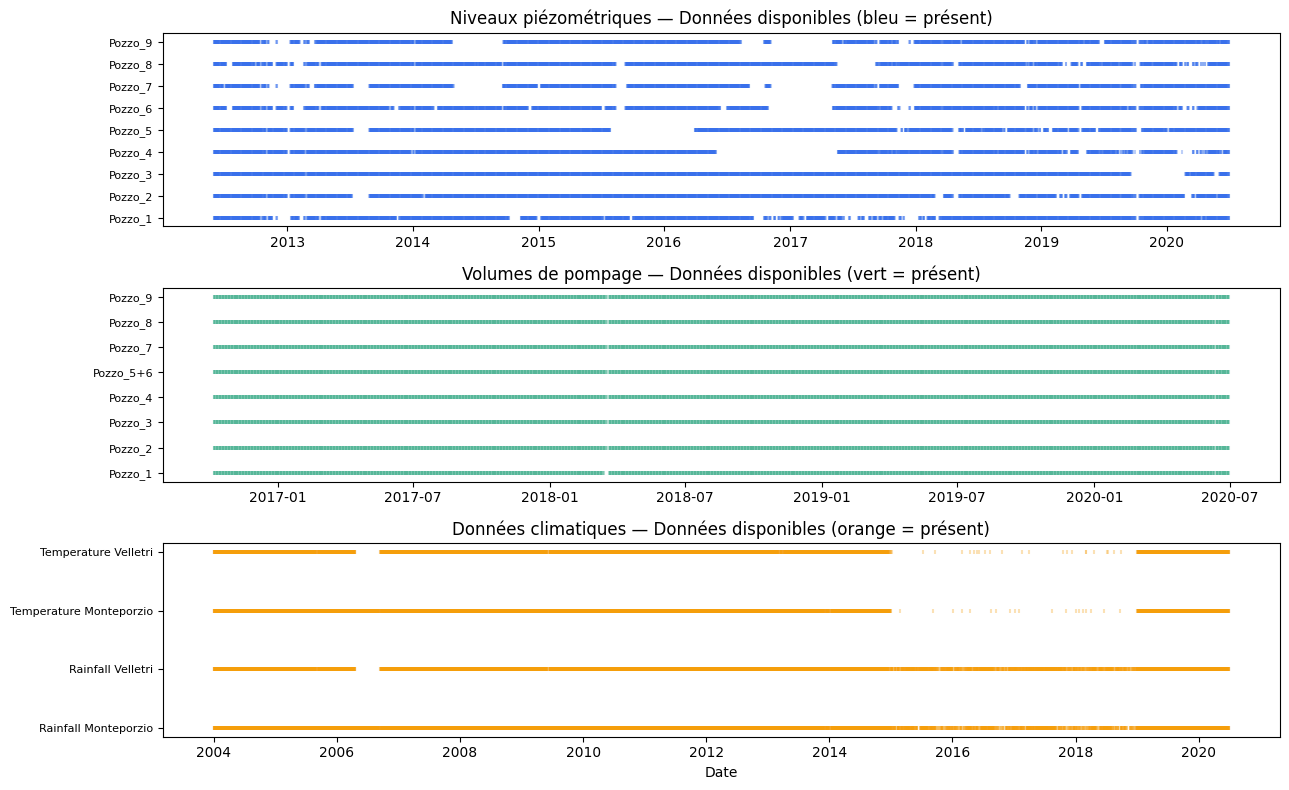

→ Figure sauvegardée dans data/processed/


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8))

# === Niveaux piézométriques ===
ax = axes[0]
puits_cols = [col for col in df_dog.columns if 'Depth_to_Groundwater' in col]
for i, col in enumerate(puits_cols):
    missing_dates = df_dog[df_dog[col].isnull()]['Date']
    present_dates = df_dog[df_dog[col].notna()]['Date']
    ax.scatter(present_dates, [i]*len(present_dates), marker='|', s=5, alpha=0.3, color='#2563EB')
ax.set_yticks(range(len(puits_cols)))
ax.set_yticklabels([col.replace('Depth_to_Groundwater_', '') for col in puits_cols], fontsize=8)
ax.set_title('Niveaux piézométriques — Données disponibles (bleu = présent)')

# === Volumes de pompage ===
ax = axes[1]
volume_cols = [col for col in df_dog.columns if 'Volume' in col]
for i, col in enumerate(volume_cols):
    present_dates = df_dog[df_dog[col].notna()]['Date']
    ax.scatter(present_dates, [i]*len(present_dates), marker='|', s=5, alpha=0.3, color='#059669')
ax.set_yticks(range(len(volume_cols)))
ax.set_yticklabels([col.replace('Volume_', '') for col in volume_cols], fontsize=8)
ax.set_title('Volumes de pompage — Données disponibles (vert = présent)')

# === Climat ===
ax = axes[2]
climate_cols = ['Rainfall_Monteporzio', 'Rainfall_Velletri', 
                'Temperature_Monteporzio', 'Temperature_Velletri']
for i, col in enumerate(climate_cols):
    present_dates = df_dog[df_dog[col].notna()]['Date']
    ax.scatter(present_dates, [i]*len(present_dates), marker='|', s=5, alpha=0.3, color='#F59E0B')
ax.set_yticks(range(len(climate_cols)))
ax.set_yticklabels([col.replace('_', ' ') for col in climate_cols], fontsize=8)
ax.set_title('Données climatiques — Données disponibles (orange = présent)')
ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig('../data/processed/15_fig_doganella_disponibilite.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

## Étape 4 : Identifier la période exploitable

Les volumes de pompage ne commencent qu'en 2016-2017.  
On doit trouver la période exacte où les 3 types de données (niveaux, pompage, climat) sont disponibles simultanément.

In [9]:
# Couper à partir de 2017 (quand le pompage commence)
df_dog_cut = df_dog[df_dog['Date'] >= '2017-01-01'].copy()

print(f"Période après coupure : {df_dog_cut['Date'].min().date()} → {df_dog_cut['Date'].max().date()}")
print(f"Lignes : {len(df_dog_cut)}\n")

# Valeurs manquantes sur cette période
print("=== Niveaux piézométriques (après 2017) ===\n")
for col in puits_cols:
    nom = col.replace('Depth_to_Groundwater_', '')
    present = df_dog_cut[col].notna().sum()
    total = len(df_dog_cut)
    pct = (present / total * 100)
    print(f"  {nom:<10} → {present:>4} valeurs présentes sur {total} ({pct:.1f}%)")

print(f"\n=== Volumes de pompage (après 2017) ===\n")
for col in volume_cols:
    nom = col.replace('Volume_', '')
    present = df_dog_cut[col].notna().sum()
    total = len(df_dog_cut)
    pct = (present / total * 100)
    print(f"  {nom:<10} → {present:>4} valeurs présentes sur {total} ({pct:.1f}%)")

print(f"\n=== Données climatiques (après 2017) ===\n")
for col in climate_cols:
    nom = col.replace('_', ' ')
    present = df_dog_cut[col].notna().sum()
    total = len(df_dog_cut)
    pct = (present / total * 100)
    print(f"  {nom:<25} → {present:>4} valeurs présentes sur {total} ({pct:.1f}%)")

Période après coupure : 2017-01-01 → 2020-06-30
Lignes : 1277

=== Niveaux piézométriques (après 2017) ===

  Pozzo_1    → 1068 valeurs présentes sur 1277 (83.6%)
  Pozzo_2    → 1133 valeurs présentes sur 1277 (88.7%)
  Pozzo_3    → 1102 valeurs présentes sur 1277 (86.3%)
  Pozzo_4    →  938 valeurs présentes sur 1277 (73.5%)
  Pozzo_5    → 1143 valeurs présentes sur 1277 (89.5%)
  Pozzo_6    → 1004 valeurs présentes sur 1277 (78.6%)
  Pozzo_7    → 1056 valeurs présentes sur 1277 (82.7%)
  Pozzo_8    → 1001 valeurs présentes sur 1277 (78.4%)
  Pozzo_9    → 1037 valeurs présentes sur 1277 (81.2%)

=== Volumes de pompage (après 2017) ===

  Pozzo_1    → 1270 valeurs présentes sur 1277 (99.5%)
  Pozzo_2    → 1274 valeurs présentes sur 1277 (99.8%)
  Pozzo_3    → 1274 valeurs présentes sur 1277 (99.8%)
  Pozzo_4    → 1274 valeurs présentes sur 1277 (99.8%)
  Pozzo_5+6  → 1274 valeurs présentes sur 1277 (99.8%)
  Pozzo_7    → 1274 valeurs présentes sur 1277 (99.8%)
  Pozzo_8    → 1274 valeu

## Étape 5 : Nettoyage du dataset Doganella

### Plan de nettoyage :
1. Couper la période avant 2017
2. Garder uniquement les colonnes utiles (pas de température, une seule pluie)
3. Interpoler les valeurs manquantes restantes
4. Vérifier qu'il reste 0 NaN
5. Sauvegarder le dataset propre

In [12]:
# === Nettoyage de Doganella ===

# 1. Couper avant 2017
df_clean = df_dog[df_dog['Date'] >= '2017-01-01'].copy()

# 2. Sélectionner les colonnes utiles
colonnes_a_garder = (
    ['Date'] +
    ['Rainfall_Velletri'] +                                    # 1 station de pluie
    [col for col in df_clean.columns if 'Depth_to_Groundwater' in col] +  # 9 niveaux
    [col for col in df_clean.columns if 'Volume' in col]                  # 8 volumes
)

df_clean = df_clean[colonnes_a_garder]

print(f"=== Après sélection des colonnes ===\n")
print(f"Lignes   : {df_clean.shape[0]}")
print(f"Colonnes : {df_clean.shape[1]}")
print(f"\nColonnes gardées :")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2d}. {col}")

# 3. NaN avant interpolation
print(f"\nNaN totaux avant interpolation : {df_clean.drop(columns='Date').isnull().sum().sum()}")

# 4. Interpolation
colonnes_num = df_clean.columns.drop('Date')
df_clean[colonnes_num] = df_clean[colonnes_num].interpolate(method='linear')

# 5. Vérifier les NaN en début de série (l'interpolation ne remplit pas les NaN au tout début)
# On les remplit avec la première valeur disponible (forward fill puis backward fill)
df_clean[colonnes_num] = df_clean[colonnes_num].bfill()

print(f"NaN totaux après interpolation : {df_clean.drop(columns='Date').isnull().sum().sum()}")

# 6. Sauvegarder
output_path = '../data/processed/16_Aquifer_Doganella_clean.csv'
df_clean.to_csv(output_path, index=False)

print(f"\n→ Dataset sauvegardé : {output_path}")
print(f"  Lignes   : {df_clean.shape[0]}")
print(f"  Colonnes : {df_clean.shape[1]}")
print(f"  Période  : {df_clean['Date'].min()} → {df_clean['Date'].max()}")

=== Après sélection des colonnes ===

Lignes   : 1277
Colonnes : 19

Colonnes gardées :
   1. Date
   2. Rainfall_Velletri
   3. Depth_to_Groundwater_Pozzo_1
   4. Depth_to_Groundwater_Pozzo_2
   5. Depth_to_Groundwater_Pozzo_3
   6. Depth_to_Groundwater_Pozzo_4
   7. Depth_to_Groundwater_Pozzo_5
   8. Depth_to_Groundwater_Pozzo_6
   9. Depth_to_Groundwater_Pozzo_7
  10. Depth_to_Groundwater_Pozzo_8
  11. Depth_to_Groundwater_Pozzo_9
  12. Volume_Pozzo_1
  13. Volume_Pozzo_2
  14. Volume_Pozzo_3
  15. Volume_Pozzo_4
  16. Volume_Pozzo_5+6
  17. Volume_Pozzo_7
  18. Volume_Pozzo_8
  19. Volume_Pozzo_9

NaN totaux avant interpolation : 2271
NaN totaux après interpolation : 0

→ Dataset sauvegardé : ../data/processed/Aquifer_Doganella_clean.csv
  Lignes   : 1277
  Colonnes : 19
  Période  : 2017-01-01 00:00:00 → 2020-06-30 00:00:00


## Étape 6 : Construction du graphe du réseau de puits (Théorie des graphes)

### Objectif

Modéliser les **relations d'influence** entre les 9 puits.  
Deux puits dont les niveaux montent et descendent ensemble puisent probablement dans la même zone de la nappe.

### Méthode

1. Calculer la corrélation entre les niveaux de chaque paire de puits
2. Si corrélation > 0.7 -> créer une arête (les puits sont connectés)
3. Le poids de l'arête = la valeur de la corrélation
4. Analyser le graphe : centralité, communautés

### Outil : NetworkX

NetworkX est une bibliothèque Python pour créer et analyser des graphes.  

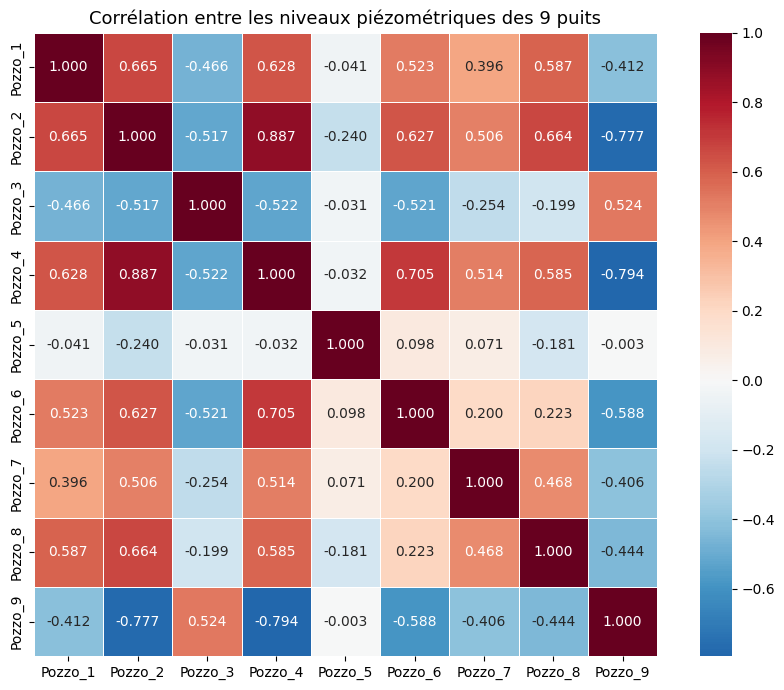

→ Figure sauvegardée

Corrélations > 0.7 (puits fortement connectés) :
  Pozzo_2 ↔ Pozzo_4 : 0.887
  Pozzo_2 ↔ Pozzo_9 : -0.777
  Pozzo_4 ↔ Pozzo_6 : 0.705
  Pozzo_4 ↔ Pozzo_9 : -0.794


In [15]:
# D'abord, calculons la matrice de corrélation entre les 9 puits
import seaborn as sns

puits_cols_dog = [col for col in df_clean.columns if 'Depth_to_Groundwater' in col]

corr_puits = df_clean[puits_cols_dog].corr().round(3)

# Visualiser
plt.figure(figsize=(9, 7))
sns.heatmap(corr_puits, annot=True, cmap='RdBu_r', center=0, 
            fmt='.3f', square=True, linewidths=0.5,
            xticklabels=[col.replace('Depth_to_Groundwater_', '') for col in puits_cols_dog],
            yticklabels=[col.replace('Depth_to_Groundwater_', '') for col in puits_cols_dog])
plt.title('Corrélation entre les niveaux piézométriques des 9 puits', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/16_fig_doganella_correlation_puits.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée")
print(f"\nCorrélations > 0.7 (puits fortement connectés) :")
for i in range(len(puits_cols_dog)):
    for j in range(i+1, len(puits_cols_dog)):
        c = corr_puits.iloc[i, j]
        if abs(c) > 0.7:
            nom_i = puits_cols_dog[i].replace('Depth_to_Groundwater_', '')
            nom_j = puits_cols_dog[j].replace('Depth_to_Groundwater_', '')
            print(f"  {nom_i} ↔ {nom_j} : {c}")

## Étape 7 : Construction du graphe avec NetworkX

### Ce que fait le code, étape par étape

**1. Créer un graphe vide**
On va créer un graphe non orienté les connexions n'ont pas de direction (si Puits_1 influence Puits_2, alors Puits_2 influence aussi Puits_1).

**2. Ajouter les nœuds**
Chaque puits devient un nœud du graphe.  

**3. Ajouter les arêtes (connexions)**.

On utilise la **valeur absolue** de la corrélation parce que :
- Corrélation +0.887 → les deux montent/descendent ensemble (même zone)
- Corrélation -0.777 → quand l'un monte, l'autre descend (zones liées)
- Dans les deux cas, les puits **s'influencent** mutuellement

**4. Calculer la centralité de degré**

Un puits avec une centralité élevée est **stratégique** :
- Il influence beaucoup de voisins
- Pomper trop de ce puits affecte tout le réseau
- L'AG devra être prudent avec lui

Un puits avec une centralité de 0 est **isolé** :
- Il n'influence aucun autre puits
- On peut le pomper indépendamment

In [40]:
import networkx as nx

# === Construire le graphe ===
G = nx.Graph()

# Ajouter les 9 puits comme nœuds
puits_noms = [col.replace('Depth_to_Groundwater_', '') for col in puits_cols_dog]
for nom in puits_noms:
    G.add_node(nom)

# Ajouter les arêtes (|corrélation| > 0.6)
SEUIL_CORRELATION = 0.6
aretes = []

for i in range(len(puits_cols_dog)):
    for j in range(i+1, len(puits_cols_dog)):
        c = corr_puits.iloc[i, j]
        if abs(c) > SEUIL_CORRELATION:
            nom_i = puits_noms[i]
            nom_j = puits_noms[j]
            G.add_edge(nom_i, nom_j, weight=round(abs(c), 3), correlation=round(c, 3))
            aretes.append((nom_i, nom_j, round(c, 3)))

print(f"=== Graphe du réseau de puits ===\n")
print(f"  Nœuds (puits) : {G.number_of_nodes()}")
print(f"  Arêtes (connexions) : {G.number_of_edges()}")
print(f"  Seuil de corrélation : |r| > {SEUIL_CORRELATION}")

print(f"\n  Connexions :")
for n1, n2, c in aretes:
    signe = "+" if c > 0 else ""
    print(f"    {n1} ↔ {n2} : {signe}{c}")

# === Métriques du graphe ===
print(f"\n=== Centralité de degré (nombre de connexions) ===\n")
degree_cent = nx.degree_centrality(G)
for nom, cent in sorted(degree_cent.items(), key=lambda x: x[1], reverse=True):
    n_connexions = G.degree(nom)
    print(f"  {nom:<10} → {n_connexions} connexions (centralité = {cent:.3f})")

# Puits isolés
isoles = [nom for nom, deg in G.degree() if deg == 0]
if isoles:
    print(f"\n  Puits isolés (aucune connexion) : {isoles}")

=== Graphe du réseau de puits ===

  Nœuds (puits) : 9
  Arêtes (connexions) : 8
  Seuil de corrélation : |r| > 0.6

  Connexions :
    Pozzo_1 ↔ Pozzo_2 : +0.665
    Pozzo_1 ↔ Pozzo_4 : +0.628
    Pozzo_2 ↔ Pozzo_4 : +0.887
    Pozzo_2 ↔ Pozzo_6 : +0.627
    Pozzo_2 ↔ Pozzo_8 : +0.664
    Pozzo_2 ↔ Pozzo_9 : -0.777
    Pozzo_4 ↔ Pozzo_6 : +0.705
    Pozzo_4 ↔ Pozzo_9 : -0.794

=== Centralité de degré (nombre de connexions) ===

  Pozzo_2    → 5 connexions (centralité = 0.625)
  Pozzo_4    → 4 connexions (centralité = 0.500)
  Pozzo_1    → 2 connexions (centralité = 0.250)
  Pozzo_6    → 2 connexions (centralité = 0.250)
  Pozzo_9    → 2 connexions (centralité = 0.250)
  Pozzo_8    → 1 connexions (centralité = 0.125)
  Pozzo_3    → 0 connexions (centralité = 0.000)
  Pozzo_5    → 0 connexions (centralité = 0.000)
  Pozzo_7    → 0 connexions (centralité = 0.000)

  Puits isolés (aucune connexion) : ['Pozzo_3', 'Pozzo_5', 'Pozzo_7']


## Étape 8 : Visualisation du graphe


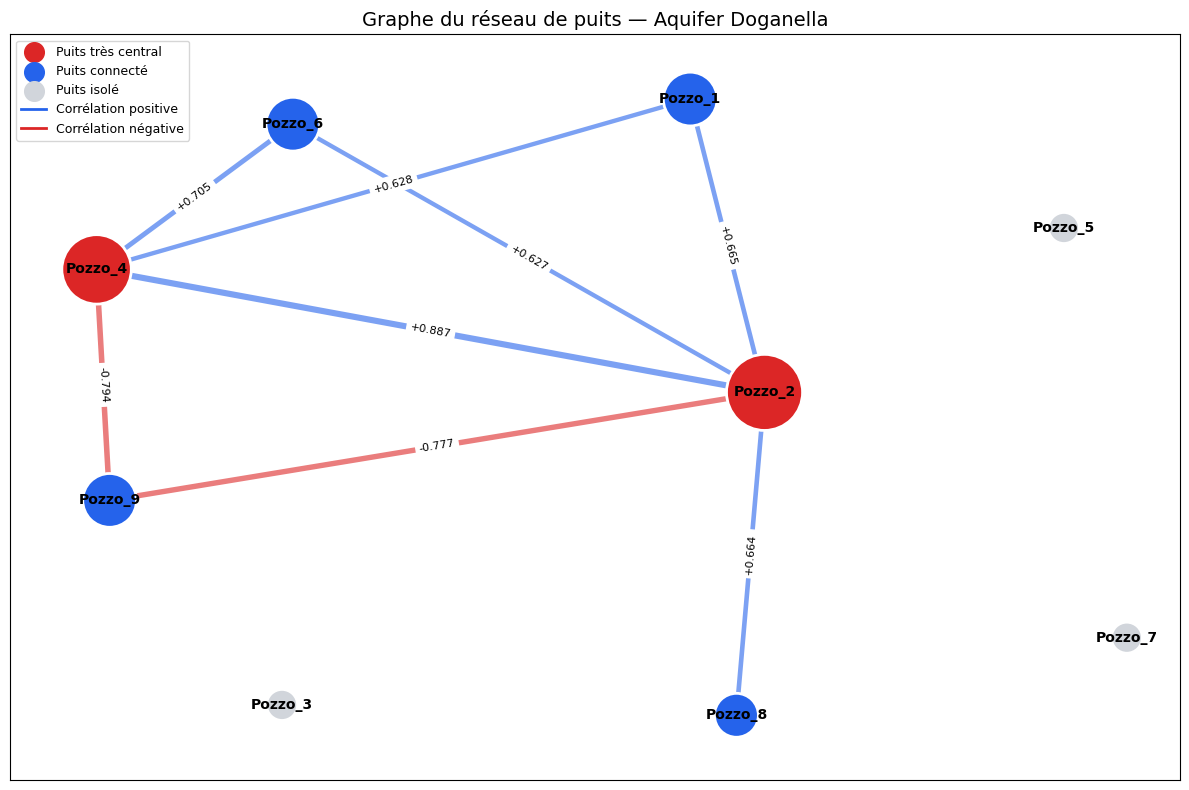

→ Figure sauvegardée dans data/processed/


In [19]:
# === Visualisation du graphe ===

fig, ax = plt.subplots(figsize=(12, 8))

# Position des nœuds (disposition automatique)
pos = nx.spring_layout(G, seed=42, k=2)

# Taille des nœuds proportionnelle à la centralité (min 500, max 3000)
node_sizes = []
for nom in G.nodes():
    cent = degree_cent[nom]
    size = 500 + cent * 4000
    node_sizes.append(size)

# Couleur des nœuds selon la centralité
node_colors = []
for nom in G.nodes():
    if degree_cent[nom] == 0:
        node_colors.append('#D1D5DB')     # Gris pour isolés
    elif degree_cent[nom] >= 0.5:
        node_colors.append('#DC2626')     # Rouge pour très central
    else:
        node_colors.append('#2563EB')     # Bleu pour connecté

# Arêtes : épaisseur et couleur
edge_widths = []
edge_colors = []
for u, v, data in G.edges(data=True):
    edge_widths.append(data['weight'] * 5)
    if data['correlation'] > 0:
        edge_colors.append('#2563EB')     # Bleu = corrélation positive
    else:
        edge_colors.append('#DC2626')     # Rouge = corrélation négative

# Dessiner
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, 
                       alpha=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, 
                       edgecolors='white', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)

# Ajouter les poids sur les arêtes
edge_labels = {}
for u, v, data in G.edges(data=True):
    signe = "+" if data['correlation'] > 0 else ""
    edge_labels[(u, v)] = f"{signe}{data['correlation']}"
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8, ax=ax)

ax.set_title('Graphe du réseau de puits — Aquifer Doganella', fontsize=14)
ax.legend(handles=[
    plt.scatter([], [], s=200, c='#DC2626', label='Puits très central'),
    plt.scatter([], [], s=200, c='#2563EB', label='Puits connecté'),
    plt.scatter([], [], s=200, c='#D1D5DB', label='Puits isolé'),
    plt.Line2D([0], [0], color='#2563EB', linewidth=2, label='Corrélation positive'),
    plt.Line2D([0], [0], color='#DC2626', linewidth=2, label='Corrélation négative'),
], loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/17_fig_doganella_graphe.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

## Étape 9 : Entraînement d'un LSTM par puits de Doganella

### Pourquoi un LSTM par puits ?

Chaque puits a son propre comportement :
- Sa profondeur est différente
- Sa géologie locale est différente
- Sa réponse au pompage est différente

Si on entraîne un seul LSTM pour tous les puits, il va apprendre un comportement "moyen" qui ne sera précis pour aucun puits.  
En entraînant un LSTM par puits, chaque modèle se spécialise sur le comportement spécifique de son puits.

### Ce que chaque LSTM va apprendre

Pour le LSTM du Puits i, on lui donne :

**Features d'entrée (X) :**
- La pluie (Rainfall_Velletri)
- Le volume de pompage du puits i (extraction directe)
- Le volume de pompage des puits voisins (du graphe)
- Le mois encodé en sin/cos (saisonnalité)
- Le niveau passé du puits i

**Target (Y) :**
- Le niveau du puits i au jour suivant

### Le rôle du graphe ici

Le graphe nous dit quels puits inclure comme "voisins".  
Pour le LSTM de Pozzo_2 (5 connexions), on inclut le pompage de Pozzo_1, Pozzo_4, Pozzo_6, Pozzo_8, Pozzo_9 comme features.  
Pour le LSTM de Pozzo_3 (isolé), il n'y a pas de voisins — on n'inclut que son propre pompage.

### Configuration LSTM (identique à Petrignano)

La même architecture gagnante qu'on a trouvée :
- 1 couche LSTM, 128 neurones, dropout = 0.1
- Fenêtre temporelle : 30 jours
- Batch size : 16, Seed : 7
- Early stopping (patience=20) + ReduceLROnPlateau

## Préparation des features pour chaque LSTM

### Features de chaque LSTM

| Puits | Voisins dans le graphe | Features incluses |
|-------|----------------------|-------------------|
| Pozzo_1 | Pozzo_2, Pozzo_4 | Pluie, Vol_1, Vol_2, Vol_4, Mois_sin/cos, Niveau_1 |
| Pozzo_2 | Pozzo_1, Pozzo_4, Pozzo_6, Pozzo_8, Pozzo_9 | Pluie, Vol_2, Vol_1, Vol_4, Vol_6, Vol_8, Vol_9, Mois_sin/cos, Niveau_2 |
| Pozzo_3 | Aucun (isolé) | Pluie, Vol_3, Mois_sin/cos, Niveau_3 |
| Pozzo_4 | Pozzo_1, Pozzo_2, Pozzo_6, Pozzo_9 | Pluie, Vol_4, Vol_1, Vol_2, Vol_6, Vol_9, Mois_sin/cos, Niveau_4 |
| Pozzo_5 | Aucun (isolé) | Pluie, Vol_5+6, Mois_sin/cos, Niveau_5 |
| Pozzo_6 | Pozzo_2, Pozzo_4 | Pluie, Vol_5+6, Vol_2, Vol_4, Mois_sin/cos, Niveau_6 |
| Pozzo_7 | Aucun (isolé) | Pluie, Vol_7, Mois_sin/cos, Niveau_7 |
| Pozzo_8 | Pozzo_2 | Pluie, Vol_8, Vol_2, Mois_sin/cos, Niveau_8 |
| Pozzo_9 | Pozzo_2, Pozzo_4 | Pluie, Vol_9, Vol_2, Vol_4, Mois_sin/cos, Niveau_9 |

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random, os

# Fixer la graine pour la reproductibilité
SEED = 7
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Encodage cyclique du mois
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Mois_sin'] = np.sin(2 * np.pi * df_clean['Date'].dt.month / 12)
df_clean['Mois_cos'] = np.cos(2 * np.pi * df_clean['Date'].dt.month / 12)

print("=== Données préparées ===")
print(f"  Colonnes disponibles : {list(df_clean.columns)}")

# Définir les voisins de chaque puits (basé sur le graphe)
# Clé = nom du puits, Valeur = liste des voisins
VOISINS = {}
for noeud in G.nodes():
    voisins_list = list(G.neighbors(noeud))
    VOISINS[noeud] = voisins_list

print(f"\n=== Voisins par puits (issus du graphe) ===\n")
for puits, voisins in VOISINS.items():
    if voisins:
        print(f"  {puits:<10} → voisins : {voisins}")
    else:
        print(f"  {puits:<10} → isolé (aucun voisin)")

=== Données préparées ===
  Colonnes disponibles : ['Date', 'Rainfall_Velletri', 'Depth_to_Groundwater_Pozzo_1', 'Depth_to_Groundwater_Pozzo_2', 'Depth_to_Groundwater_Pozzo_3', 'Depth_to_Groundwater_Pozzo_4', 'Depth_to_Groundwater_Pozzo_5', 'Depth_to_Groundwater_Pozzo_6', 'Depth_to_Groundwater_Pozzo_7', 'Depth_to_Groundwater_Pozzo_8', 'Depth_to_Groundwater_Pozzo_9', 'Volume_Pozzo_1', 'Volume_Pozzo_2', 'Volume_Pozzo_3', 'Volume_Pozzo_4', 'Volume_Pozzo_5+6', 'Volume_Pozzo_7', 'Volume_Pozzo_8', 'Volume_Pozzo_9', 'Mois_sin', 'Mois_cos']

=== Voisins par puits (issus du graphe) ===

  Pozzo_1    → voisins : ['Pozzo_2', 'Pozzo_4']
  Pozzo_2    → voisins : ['Pozzo_1', 'Pozzo_4', 'Pozzo_6', 'Pozzo_8', 'Pozzo_9']
  Pozzo_3    → isolé (aucun voisin)
  Pozzo_4    → voisins : ['Pozzo_1', 'Pozzo_2', 'Pozzo_6', 'Pozzo_9']
  Pozzo_5    → isolé (aucun voisin)
  Pozzo_6    → voisins : ['Pozzo_2', 'Pozzo_4']
  Pozzo_7    → isolé (aucun voisin)
  Pozzo_8    → voisins : ['Pozzo_2']
  Pozzo_9    → voisins 

## Étape 10a : Test sur un seul puits — Pozzo_1


In [21]:
# === Étape 1 : Sélectionner les colonnes de Pozzo_1 ===

puits = 'Pozzo_1'
niveau_col  = 'Depth_to_Groundwater_Pozzo_1'
vol_col     = 'Volume_Pozzo_1'
voisins     = VOISINS['Pozzo_1']          # ['Pozzo_2', 'Pozzo_4']

# Colonnes des volumes de pompage des voisins
voisins_vol = ['Volume_Pozzo_2', 'Volume_Pozzo_4']

# Construire la liste complète des colonnes
# IMPORTANT : le niveau est TOUJOURS en dernière position (c'est la target)
feature_cols = (
    ['Rainfall_Velletri'] +   # pluie
    [vol_col] +               # pompage propre
    voisins_vol +             # pompage des voisins
    ['Mois_sin', 'Mois_cos'] + # saisonnalité
    [niveau_col]              # target (dernière colonne)
)

print(f"=== Features pour {puits} ===\n")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

print(f"\n→ Nombre total de features : {len(feature_cols)}")
print(f"→ Target : {feature_cols[-1]} (dernière colonne)")

=== Features pour Pozzo_1 ===

  1. Rainfall_Velletri
  2. Volume_Pozzo_1
  3. Volume_Pozzo_2
  4. Volume_Pozzo_4
  5. Mois_sin
  6. Mois_cos
  7. Depth_to_Groundwater_Pozzo_1

→ Nombre total de features : 7
→ Target : Depth_to_Groundwater_Pozzo_1 (dernière colonne)


## Étape 10b : Extraction des données et split train/test



In [22]:
# Extraire les données de Pozzo_1
data_p1 = df_clean[feature_cols].values

print(f"=== Données extraites ===")
print(f"  Shape : {data_p1.shape}")
print(f"  Lignes : {data_p1.shape[0]}")
print(f"  Colonnes : {data_p1.shape[1]}")

# Split chronologique 80/20
SPLIT = 0.8
split_idx = int(len(data_p1) * SPLIT)

train_p1 = data_p1[:split_idx]
test_p1  = data_p1[split_idx:]

# Dates correspondantes
date_coupure = df_clean['Date'].iloc[split_idx]

print(f"\n=== Split train/test ===")
print(f"  Train : {train_p1.shape[0]} lignes")
print(f"    → du {df_clean['Date'].iloc[0].date()} au {df_clean['Date'].iloc[split_idx-1].date()}")
print(f"  Test  : {test_p1.shape[0]} lignes")
print(f"    → du {date_coupure.date()} au {df_clean['Date'].iloc[-1].date()}")

=== Données extraites ===
  Shape : (1277, 7)
  Lignes : 1277
  Colonnes : 7

=== Split train/test ===
  Train : 1021 lignes
    → du 2017-01-01 au 2019-10-18
  Test  : 256 lignes
    → du 2019-10-19 au 2020-06-30


## Étape 10c : Normalisation des données de Pozzo_1

Comme pour Petrignano, on normalise entre 0 et 1.
Le scaler est ajusté sur le train uniquement.


In [23]:
from sklearn.preprocessing import MinMaxScaler

# Normalisation
scaler_p1 = MinMaxScaler(feature_range=(0, 1))
train_p1_scaled = scaler_p1.fit_transform(train_p1)
test_p1_scaled  = scaler_p1.transform(test_p1)

# Vérification
print(f"=== Normalisation ===")
print(f"  Train avant : min={train_p1.min():.2f}, max={train_p1.max():.2f}")
print(f"  Train après : min={train_p1_scaled.min():.2f}, max={train_p1_scaled.max():.2f}")
print(f"  Test après  : min={test_p1_scaled.min():.4f}, max={test_p1_scaled.max():.4f}")
print(f"\n→ Note : Le test peut dépasser légèrement [0,1] si")
print(f"  ses valeurs sont hors de la plage du train — c'est normal")

=== Normalisation ===
  Train avant : min=-54.98, max=4171.28
  Train après : min=0.00, max=1.00
  Test après  : min=-0.1667, max=1.0640

→ Note : Le test peut dépasser légèrement [0,1] si
  ses valeurs sont hors de la plage du train — c'est normal


## Étape 10d : Création des séquences 3D pour Pozzo_1

On découpe les données normalisées en fenêtres glissantes de 30 jours.


In [24]:
def create_sequences(data, window_size=30):
    """
    Découpe les données en séquences glissantes.
    
    Paramètres :
    - data : tableau normalisé (lignes × colonnes)
    - window_size : nombre de jours par séquence (30)
    
    Retourne :
    - X : séquences de features (n_séquences × 30 × n_features)
    - y : target à prédire (n_séquences,)
          = la dernière colonne du jour suivant la séquence
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        # Séquence : 30 jours × toutes les colonnes
        X.append(data[i - window_size:i, :])
        # Target : la dernière colonne (niveau P24) du jour i
        y.append(data[i, -1])
    return np.array(X), np.array(y)

# Créer les séquences
WINDOW = 30
X_train_p1, y_train_p1 = create_sequences(train_p1_scaled, WINDOW)
X_test_p1,  y_test_p1  = create_sequences(test_p1_scaled,  WINDOW)

print(f"=== Séquences créées ===\n")
print(f"  X_train : {X_train_p1.shape}")
print(f"    → {X_train_p1.shape[0]} séquences")
print(f"    → {X_train_p1.shape[1]} jours par séquence")
print(f"    → {X_train_p1.shape[2]} features par jour")
print(f"\n  y_train : {y_train_p1.shape}")
print(f"\n  X_test  : {X_test_p1.shape}")
print(f"  y_test  : {y_test_p1.shape}")

=== Séquences créées ===

  X_train : (991, 30, 7)
    → 991 séquences
    → 30 jours par séquence
    → 7 features par jour

  y_train : (991,)

  X_test  : (226, 30, 7)
  y_test  : (226,)


## Étape 10e : Construction et entraînement du LSTM de Pozzo_1

### Architecture choisie

Même architecture que Petrignano mais légèrement adaptée pour compenser les données limitées (991 séquences vs 3305) :

- 1 couche LSTM : 128 neurones
- Dropout : 0.2 (augmenté de 0.1 à 0.2 → plus de régularisation)
- Dense : 1 neurone (prédiction du niveau)
- Patience early stopping : 10 (réduit de 20 → arrêt plus rapide)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Fixer la graine
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Construire le modèle
n_features_p1 = X_train_p1.shape[2]   # = 7

model_p1 = Sequential([
    LSTM(128, input_shape=(WINDOW, n_features_p1)),
    Dropout(0.2),
    Dense(1)
])
model_p1.compile(optimizer='adam', loss='mse')

print(f"=== Architecture du LSTM — Pozzo_1 ===\n")
model_p1.summary()

# Entraîner
print(f"\n=== Entraînement ===\n")
history_p1 = model_p1.fit(
    X_train_p1, y_train_p1,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=5, min_lr=0.00001)
    ],
    verbose=1
)

print(f"\n→ Entraînement terminé en {len(history_p1.history['loss'])} époques")

=== Architecture du LSTM — Pozzo_1 ===



d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,761 (272.50 KB)

 Trainable params: 69,761 (272.50 KB)

 Non-trainable params: 0 (0.00 B)


=== Entraînement ===

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0225 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0065 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0059 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0049 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0046 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0036 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - val_loss: 0.0016 - learning_rate: 0.

## Étape 10f : Évaluation du LSTM de Pozzo_1

On mesure les performances sur les données de test (2019-10 → 2020-06).

### La dé-normalisation

Le LSTM prédit des valeurs entre 0 et 1 (normalisées).  
On doit les reconvertir en mètres.

=== Résultats LSTM — Pozzo_1 ===

  R²   : 0.9219
  RMSE : 1.3006 m
  MAE  : 0.9256 m

  → Bon résultat (R² ≥ 0.80) — on garde 128 neurones


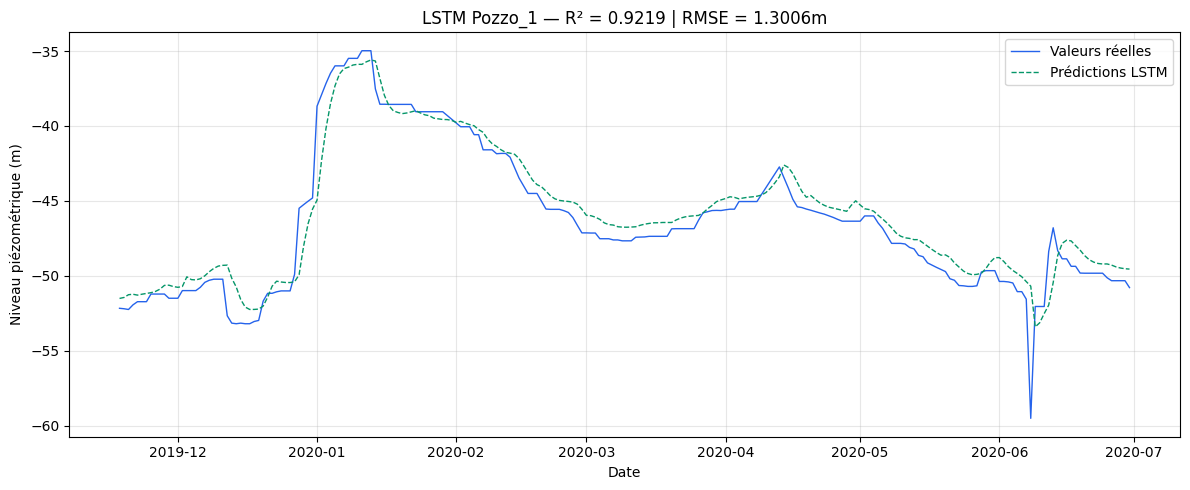

In [26]:
# === Prédictions ===
pred_scaled_p1 = model_p1.predict(X_test_p1, verbose=0)

# === Dé-normalisation ===
# Créer un tableau vide de n_features colonnes
dummy_pred = np.zeros((len(pred_scaled_p1), n_features_p1))
dummy_pred[:, -1] = pred_scaled_p1.flatten()
y_pred_p1 = scaler_p1.inverse_transform(dummy_pred)[:, -1]

# Dé-normaliser aussi les vraies valeurs
dummy_true = np.zeros((len(y_test_p1), n_features_p1))
dummy_true[:, -1] = y_test_p1
y_real_p1 = scaler_p1.inverse_transform(dummy_true)[:, -1]

# === Métriques ===
rmse_p1 = np.sqrt(mean_squared_error(y_real_p1, y_pred_p1))
mae_p1  = mean_absolute_error(y_real_p1, y_pred_p1)
r2_p1   = r2_score(y_real_p1, y_pred_p1)

print(f"=== Résultats LSTM — Pozzo_1 ===\n")
print(f"  R²   : {r2_p1:.4f}")
print(f"  RMSE : {rmse_p1:.4f} m")
print(f"  MAE  : {mae_p1:.4f} m")

if r2_p1 >= 0.80:
    print(f"\n  → Bon résultat (R² ≥ 0.80) — on garde 128 neurones")
else:
    print(f"\n  → R² < 0.80 — on testera 64 neurones")

# === Visualisation ===
dates_test_p1 = df_clean['Date'].iloc[split_idx + WINDOW:].values

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates_test_p1, y_real_p1,
        color='#2563EB', linewidth=1, label='Valeurs réelles')
ax.plot(dates_test_p1, y_pred_p1,
        color='#059669', linewidth=1, linestyle='--', label='Prédictions LSTM')
ax.set_title(f'LSTM Pozzo_1 — R² = {r2_p1:.4f} | RMSE = {rmse_p1:.4f}m')
ax.set_ylabel('Niveau piézométrique (m)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('../data/processed/fig_lstm_pozzo1.png', dpi=150, bbox_inches='tight')
plt.show()

# print("→ Figure sauvegardée")

In [32]:
# === Test rapide : 3 seeds pour Pozzo_1 ===

print("=== Test de stabilité — 3 seeds pour Pozzo_1 ===\n")
print(f"{'Seed':>6} {'R²':>8} {'RMSE':>8} {'Époques':>8}")
print(f"{'─'*35}")

best_r2_p1 = -999
best_model_p1 = None
best_scaler_p1 = scaler_p1

for seed in [7, 42, 123]:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    m = Sequential([
        LSTM(128, input_shape=(WINDOW, n_features_p1)),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')

    h = m.fit(
        X_train_p1, y_train_p1,
        epochs=200,
        batch_size=16,
        validation_split=0.2,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=10,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                             patience=5, min_lr=0.00001)
        ],
        verbose=0
    )

    pred_sc = m.predict(X_test_p1, verbose=0)
    dummy = np.zeros((len(pred_sc), n_features_p1))
    dummy[:, -1] = pred_sc.flatten()
    pred = scaler_p1.inverse_transform(dummy)[:, -1]

    r2   = r2_score(y_real_p1, pred)
    rmse = np.sqrt(mean_squared_error(y_real_p1, pred))
    ep   = len(h.history['loss'])

    print(f"  {seed:>6} {r2:>8.4f} {rmse:>8.4f} {ep:>8}")

    if r2 > best_r2_p1:
        best_r2_p1 = r2
        best_model_p1 = m
        best_pred_p1 = pred

print(f"\n  → Meilleur R² : {best_r2_p1:.4f}")

=== Test de stabilité — 3 seeds pour Pozzo_1 ===

  Seed       R²     RMSE  Époques
───────────────────────────────────


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


       7   0.9219   1.3006       54


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


      42   0.9221   1.2990       51


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     123   0.8780   1.6253       51

  → Meilleur R² : 0.9221


#### Ce qu'on observe : 
Excellent. Les résultats sont stables entre seed 7 et seed 42 (0.9219 vs 0.9221 — quasiment identiques). Seed 123 est moins bon. Le modèle est fiable.  
La graine 42 donne le meilleur R² (0.9221). On utilisera la seed 42 pour Pozzo_1. On peut maintenant généraliser aux 8 autres puits avec la même approche.

## Étape 10g : Entraînement des LSTM pour tous les puits

Maintenant qu'on a validé le pipeline sur Pozzo_1, on applique exactement la même approche aux 8 puits restants.


In [33]:
# Mapping volume par puits
VOLUME_MAP = {
    'Pozzo_1': 'Volume_Pozzo_1',
    'Pozzo_2': 'Volume_Pozzo_2',
    'Pozzo_3': 'Volume_Pozzo_3',
    'Pozzo_4': 'Volume_Pozzo_4',
    'Pozzo_5': 'Volume_Pozzo_5+6',
    'Pozzo_6': 'Volume_Pozzo_5+6',
    'Pozzo_7': 'Volume_Pozzo_7',
    'Pozzo_8': 'Volume_Pozzo_8',
    'Pozzo_9': 'Volume_Pozzo_9',
}

# Stocker les résultats, scalers et modèles
resultats = {}
scalers_dog = {}
modeles_dog = {}
preds_dog = {}
reals_dog = {}

SPLIT = 0.8

print("=== Entraînement des 9 LSTM (3 seeds chacun) ===\n")
print(f"  {'Puits':<10} {'Features':>9} {'Best seed':>10} "
      f"{'R²':>8} {'RMSE':>8} {'Époques':>8}")
print(f"  {'─'*60}")

for puits in puits_noms:

    # === Features ===
    niveau_col   = f'Depth_to_Groundwater_{puits}'
    vol_col      = VOLUME_MAP[puits]
    voisins      = VOISINS[puits]
    voisins_vol  = [VOLUME_MAP[v] for v in voisins]

    feature_cols = (
        ['Rainfall_Velletri'] +
        [vol_col] +
        voisins_vol +
        ['Mois_sin', 'Mois_cos'] +
        [niveau_col]
    )

    data = df_clean[feature_cols].values
    n_feat = data.shape[1]

    # === Split et normalisation ===
    split_idx     = int(len(data) * SPLIT)
    train_data    = data[:split_idx]
    test_data     = data[split_idx:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_sc = scaler.fit_transform(train_data)
    test_sc  = scaler.transform(test_data)

    # === Séquences ===
    X_tr, y_tr = create_sequences(train_sc, WINDOW)
    X_te, y_te = create_sequences(test_sc,  WINDOW)

    # === 3 seeds ===
    best_r2    = -999
    best_model = None
    best_seed  = None
    best_ep    = None

    for seed in [7, 42, 123]:
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)

        m = Sequential([
            LSTM(128, input_shape=(WINDOW, n_feat)),
            Dropout(0.2),
            Dense(1)
        ])
        m.compile(optimizer='adam', loss='mse')

        h = m.fit(
            X_tr, y_tr,
            epochs=200,
            batch_size=16,
            validation_split=0.2,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=10,
                              restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=5, min_lr=0.00001)
            ],
            verbose=0
        )

        # Évaluer
        pred_sc  = m.predict(X_te, verbose=0)
        dummy    = np.zeros((len(pred_sc), n_feat))
        dummy[:, -1] = pred_sc.flatten()
        pred     = scaler.inverse_transform(dummy)[:, -1]

        dummy_t  = np.zeros((len(y_te), n_feat))
        dummy_t[:, -1] = y_te
        y_real   = scaler.inverse_transform(dummy_t)[:, -1]

        r2 = r2_score(y_real, pred)

        if r2 > best_r2:
            best_r2    = r2
            best_model = m
            best_seed  = seed
            best_ep    = len(h.history['loss'])
            best_pred  = pred
            best_real  = y_real

    # Sauvegarder
    best_model.save(f'../models/lstm_{puits.lower()}.keras')
    resultats[puits]    = {'r2': best_r2,
                           'rmse': np.sqrt(mean_squared_error(best_real, best_pred)),
                           'seed': best_seed}
    scalers_dog[puits]  = scaler
    modeles_dog[puits]  = best_model
    preds_dog[puits]    = best_pred
    reals_dog[puits]    = best_real

    rmse = resultats[puits]['rmse']
    print(f"  {puits:<10} {n_feat:>9} {best_seed:>10} "
          f"{best_r2:>8.4f} {rmse:>8.4f} {best_ep:>8}")

# Résumé
print(f"\n=== Résumé ===")
r2_moyen = np.mean([v['r2'] for v in resultats.values()])
print(f"  R² moyen : {r2_moyen:.4f}")
print(f"\n→ 9 modèles sauvegardés dans models/")

=== Entraînement des 9 LSTM (3 seeds chacun) ===

  Puits       Features  Best seed       R²     RMSE  Époques
  ────────────────────────────────────────────────────────────


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Pozzo_1            7         42   0.9221   1.2990       51


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Pozzo_2           10          7   0.0536   1.5575       27


...

  Pozzo_7            5          7   0.8265   0.1823       40


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Pozzo_8            6          7   0.2984   1.0738       48


d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\Master\PFE\GWL_Prediction_Optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Pozzo_9            7          7   0.9270   0.3063       21

=== Résumé ===
  R² moyen : 0.6610

→ 9 modèles sauvegardés dans models/


## Analyse des résultats — 9 LSTM de Doganella

### Tableau récapitulatif

| Puits   | R²     | RMSE   | Statut    |
|---------|--------|--------|-----------|
| Pozzo_1 | 0.9221 | 1.2990 | ✓ Bon     |
| Pozzo_2 | 0.0536 | 1.5575 | ✗ Mauvais |
| Pozzo_3 | 0.9727 | 0.7189 | ✓ Excellent |
| Pozzo_4 | 0.9112 | 0.2034 | ✓ Bon     |
| Pozzo_5 | 0.1003 | 0.1393 | ✗ Mauvais |
| Pozzo_6 | 0.9371 | 0.5201 | ✓ Bon     |
| Pozzo_7 | 0.8265 | 0.1823 | ✓ Acceptable |
| Pozzo_8 | 0.2984 | 1.0738 | ✗ Mauvais |
| Pozzo_9 | 0.9270 | 0.3063 | ✓ Bon     |


### Voyons le graphique des puits problèmatiques :

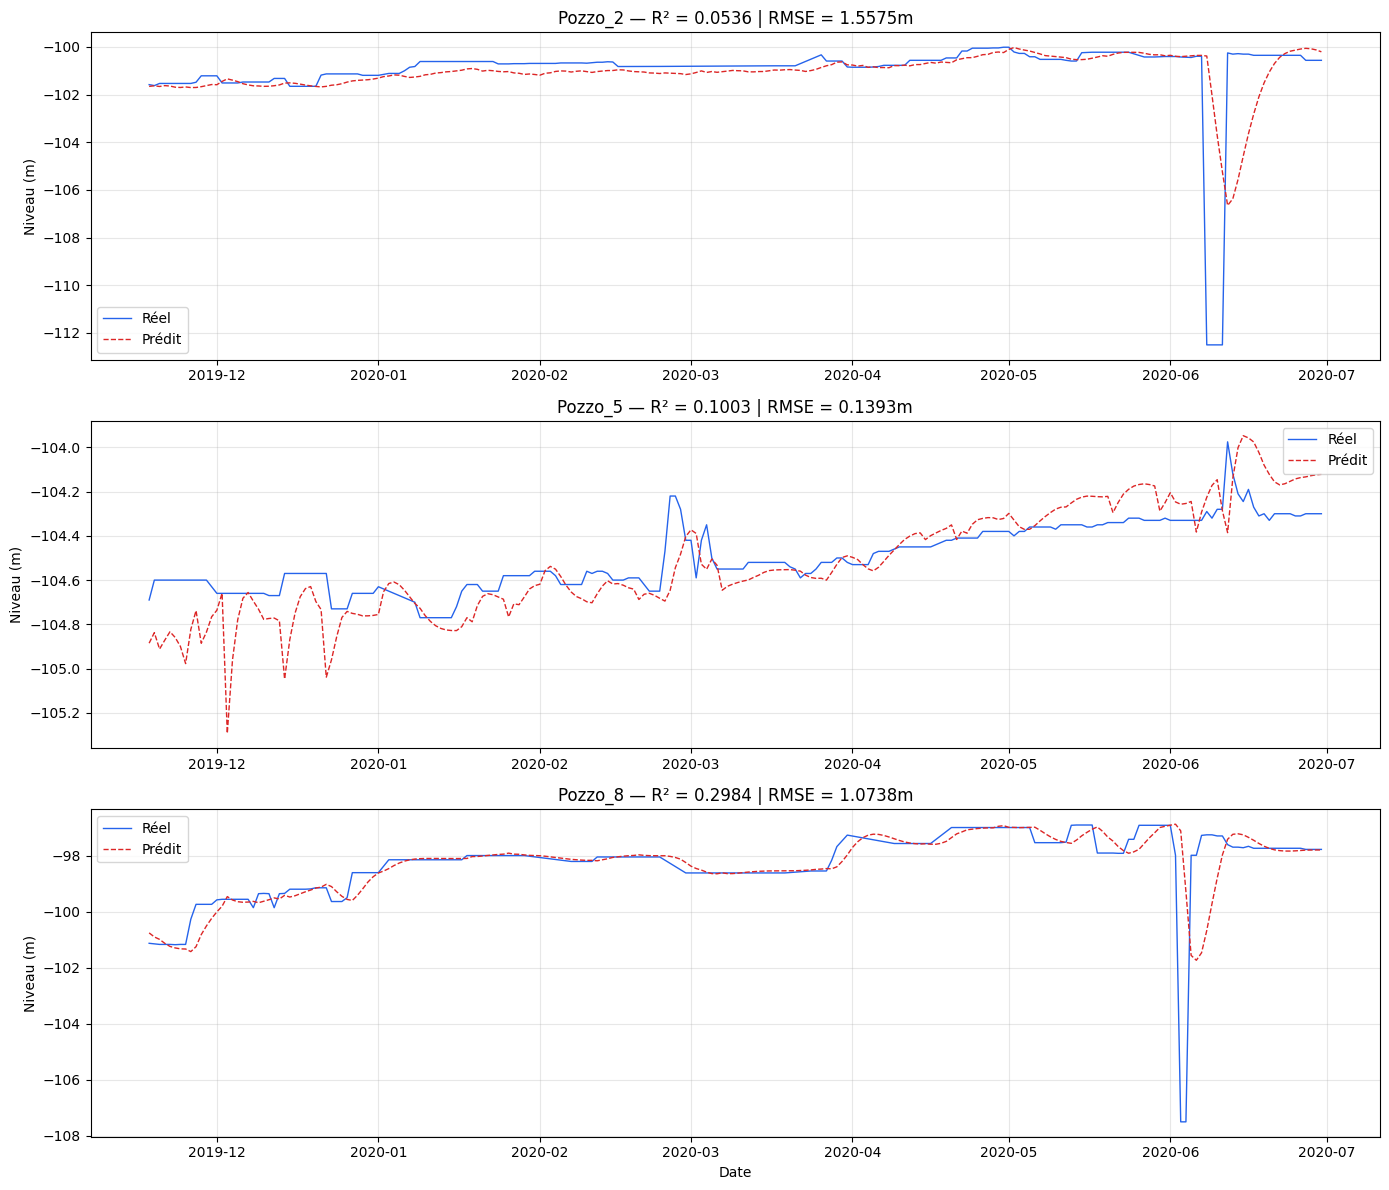

In [35]:
# Visualiser les 3 puits problématiques
problematiques = ['Pozzo_2', 'Pozzo_5', 'Pozzo_8']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, puits in enumerate(problematiques):
    pred  = preds_dog[puits]
    real  = reals_dog[puits]
    r2    = resultats[puits]['r2']
    rmse  = resultats[puits]['rmse']

    dates_test = df_clean['Date'].iloc[
        int(len(df_clean) * SPLIT) + WINDOW:
    ].values

    axes[i].plot(dates_test, real,
                 color='#2563EB', linewidth=1, label='Réel')
    axes[i].plot(dates_test, pred,
                 color='#DC2626', linewidth=1,
                 linestyle='--', label='Prédit')
    axes[i].set_title(f'{puits} — R² = {r2:.4f} | RMSE = {rmse:.4f}m')
    axes[i].set_ylabel('Niveau (m)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../data/processed/17_fig_puits_problematiques.png',
            dpi=150, bbox_inches='tight')
plt.show()

#### Ce qu'on observe :
Pozzo_2 : le LSTM suit plutôt bien la tendance générale (-100 à -101m) sauf pour la chute brutale en juin 2020 (-100 à -112m). C'est un événement extrême que le LSTM n'a jamais vu dans les données d'entraînement. Sans cet événement, le R² serait probablement beaucoup plus haut.  
Pozzo_5 : le niveau varie très peu (-104.0 à -105.2m). L'amplitude totale est de seulement 1.2 mètres. Le LSTM a du mal parce que le signal est presque plat, les variations sont du même ordre de grandeur que le bruit. Le R² est faible mais le RMSE est très petit (0.14m), le modèle ne se trompe pas beaucoup en valeur absolue.  
Pozzo_8 : même problème que Pozzo_2. La tendance est bien captée (-98 à -100m) sauf la chute brutale en juin 2020 (-98 à -108m). Un événement extrême non vu pendant l'entraînement.

**La vraie cause : les chutes brutales de juin 2020**  
Les 3 puits problématiques ont tous un point commun : une chute extrême en juin 2020 qui n'existe pas dans les données d'entraînement (2017-2019). Le LSTM ne peut pas prédire un événement qu'il n'a jamais vu.


## Décision pour la suite

### Puits retenus pour l'optimisation par AG

| Puits   | R²     | Rôle dans l'AG |
|---------|--------|----------------|
| Pozzo_1 | 0.9221 | Simulateur LSTM |
| Pozzo_3 | 0.9727 | Simulateur LSTM |
| Pozzo_4 | 0.9112 | Simulateur LSTM |
| Pozzo_6 | 0.9371 | Simulateur LSTM |
| Pozzo_7 | 0.8265 | Simulateur LSTM |
| Pozzo_9 | 0.9270 | Simulateur LSTM |

### Puits exclus de l'optimisation

| Puits   | R²     | Raison |
|---------|--------|--------|
| Pozzo_2 | 0.0536 | Chute extrême juin 2020 non représentée |
| Pozzo_5 | 0.1003 | Amplitude trop faible (1.2m) |
| Pozzo_8 | 0.2984 | Chute extrême juin 2020 non représentée |


L'optimisation est réalisée sur 6 puits disposant de simulateurs LSTM fiables (R² moyen = 0.9161).  
Cette approche garantit que les recommandations de l'AG sont basées sur des prédictions crédibles.

Les 3 puits exclus présentent des événements extrêmes dans la période de test absents des données d'entraînement, ce qui est une limitation connue des modèles de deep learning.

## Étape 11 : Implémentation de l'algorithme génétique

### Rappel du concept

L'AG cherche la meilleure répartition du pompage entre les 6 puits fiables (Pozzo_1, 3, 4, 6, 7, 9) pour :
- Satisfaire la demande totale en eau
- Ne pas descendre sous le seuil critique de chaque puits
- Respecter les contraintes de voisinage du graphe

### Les paramètres qu'on doit définir

**Paramètres de l'utilisateur** (simulés pour la démo) :
- Demande totale en eau : à calculer depuis les données historiques
- Débit max par puits : basé sur le max historique de chaque puits
- Seuil critique : le niveau minimum acceptable
- Horizon : 30 jours

**Paramètres de l'AG** :
- Taille de la population : 50 individus
- Nombre de générations : 100
- Taux de croisement : 0.7 (70% des individus se croisent)
- Taux de mutation : 0.2 (20% de chances de modifier un gène)


## Étape 11a : Définir les contraintes à partir des données réelles

On les calcule les contraintes arbitraires directement depuis les données historiques de Doganella. C'est plus réaliste et défendable scientifiquement.

1. Le débit moyen historique par puits → la demande actuelle
2. Le débit maximum par puits → la capacité physique
3. Le niveau minimum historique par puits → le seuil critique



In [46]:
# === Puits retenus pour l'optimisation ===
PUITS_AG = ['Pozzo_1', 'Pozzo_3', 'Pozzo_4', 'Pozzo_6', 'Pozzo_7', 'Pozzo_9']

print("=== Contraintes calculées depuis les données historiques ===\n")

# Débit moyen et max par puits
print(f"{'Puits':<10} {'Vol. moyen':>12} {'Vol. max':>12} {'Niveau min':>12} {'Niveau moy':>12}")
print(f"{'─'*60}")

contraintes = {}

for puits in PUITS_AG:
    vol_col = VOLUME_MAP[puits]
    niv_col = f'Depth_to_Groundwater_{puits}'
    
    vol_mean = df_clean[vol_col].mean()
    vol_max  = df_clean[vol_col].max()
    niv_min  = df_clean[niv_col].min()
    niv_mean = df_clean[niv_col].mean()
    
    contraintes[puits] = {
        'vol_mean': vol_mean,
        'vol_max': vol_max,
        'niv_min': niv_min,
        'niv_mean': niv_mean,
    }
    
    print(f"  {puits:<10} {vol_mean:>12.1f} {vol_max:>12.1f} {niv_min:>12.2f} {niv_mean:>12.2f}")

# Demande totale = somme des volumes moyens
demande_totale = sum(c['vol_mean'] for c in contraintes.values())
print(f"\n  Demande totale (somme des moyennes) : {demande_totale:.0f} m³/jour")

# Seuil critique = niveau minimum historique - 2m de marge
print(f"\n  Seuils critiques (niveau min historique - 2m de marge) :")
for puits in PUITS_AG:
    seuil = contraintes[puits]['niv_min'] - 2
    contraintes[puits]['seuil'] = seuil
    print(f"    {puits} : {seuil:.2f} m")

=== Contraintes calculées depuis les données historiques ===

Puits        Vol. moyen     Vol. max   Niveau min   Niveau moy
────────────────────────────────────────────────────────────
  Pozzo_1          1579.9       4171.3       -59.50       -41.12
  Pozzo_3          3080.8       5141.5      -117.80      -114.25
  Pozzo_4          3515.6       4076.1      -102.98      -100.55
  Pozzo_6          7324.0       8360.2       -99.48       -93.40
  Pozzo_7          2450.2       3427.4       -97.43       -96.21
  Pozzo_9          3177.2       4286.2      -105.94       -95.88

  Demande totale (somme des moyennes) : 21128 m³/jour

  Seuils critiques (niveau min historique - 2m de marge) :
    Pozzo_1 : -61.50 m
    Pozzo_3 : -119.80 m
    Pozzo_4 : -104.98 m
    Pozzo_6 : -101.48 m
    Pozzo_7 : -99.43 m
    Pozzo_9 : -107.94 m


## Étape 11b : La fonction de fitness


C'est la **note** qu'on donne à chaque individu (combinaison de pompage).  
Plus le score est élevé, meilleure est la solution.

### Comment on calcule le score ?

Pour chaque individu proposé par l'AG, on fait 4 vérifications :

**1. Vérifier la demande**
La somme des débits doit être proche de la demande totale (21128 m³).
Si la somme est trop éloignée : pénalité.

**2. Simuler avec les LSTM**
Pour chaque puits, on appelle son LSTM avec le débit proposé.  
Le LSTM prédit le niveau du puits après 30 jours.

**3. Vérifier les seuils critiques**
Si un puits descend sous son seuil : forte pénalité.

**4. Vérifier les contraintes du graphe**
Si deux puits voisins pompent tous les deux fortement → pénalité.

Score = bonus(niveau moyen élevé)  
      - pénalité(demande non satisfaite)  
      - pénalité(seuils violés)  
      - pénalité(voisinage surchargé)

### Simplification importante pour la simulation

Au lieu de simuler 30 jours récursivement (jour par jour),  
on va utiliser une approche simplifiée mais efficace :
- On prend les 30 derniers jours réels comme séquence d'entrée
- On remplace le pompage par le débit proposé par l'AG
- Le LSTM prédit le niveau du jour suivant


In [2]:
# === Fonction de simulation : appeler un LSTM avec un débit modifié ===

def simuler_puits(puits, debit_propose, debits_voisins):
    """
    Simule l'impact d'un débit de pompage sur un puits.
    
    Paramètres :
    - puits : nom du puits (ex: 'Pozzo_1')
    - debit_propose : le débit proposé par l'AG pour ce puits
    - debits_voisins : dict {nom_voisin: debit} pour les voisins
    
    Retourne :
    - niveau_predit : le niveau prédit du puits (en mètres)
    """
    
    # Récupérer le modèle et le scaler de ce puits
    model  = modeles_dog[puits]
    scaler = scalers_dog[puits]
    
    # Construire les features dans le même ordre que l'entraînement
    niveau_col = f'Depth_to_Groundwater_{puits}'
    vol_col    = VOLUME_MAP[puits]
    voisins    = VOISINS[puits]
    voisins_vol_cols = [VOLUME_MAP[v] for v in voisins]
    
    feature_cols = (
        ['Rainfall_Velletri'] +
        [vol_col] +
        voisins_vol_cols +
        ['Mois_sin', 'Mois_cos'] +
        [niveau_col]
    )
    
    # Prendre les 30 derniers jours réels comme base
    sequence = df_clean[feature_cols].values[-30:].copy()
    
    # Remplacer le pompage propre par le débit proposé
    sequence[:, 1] = debit_propose
    
    # Remplacer le pompage des voisins
    for i, voisin in enumerate(voisins):
        if voisin in debits_voisins:
            sequence[:, 2 + i] = debits_voisins[voisin]
    
    # Normaliser avec le scaler de ce puits
    sequence_scaled = scaler.transform(sequence)
    
    # Reshape pour le LSTM : (1, 30, n_features)
    X = sequence_scaled.reshape(1, 30, sequence_scaled.shape[1])
    
    # Prédire
    pred_scaled = model.predict(X, verbose=0)
    
    # Dé-normaliser
    n_feat = sequence_scaled.shape[1]
    dummy = np.zeros((1, n_feat))
    dummy[0, -1] = pred_scaled[0, 0]
    niveau_predit = scaler.inverse_transform(dummy)[0, -1]
    
    return niveau_predit


# === Test rapide sur Pozzo_1 ===
# Simuler avec le débit moyen historique
test_niveau = simuler_puits(
    'Pozzo_1',
    debit_propose=1580,              # débit moyen
    debits_voisins={'Pozzo_2': 3000, 'Pozzo_4': 3500}  # voisins au débit moyen
)
print(f"=== Test de la fonction de simulation ===\n")
print(f"  Pozzo_1 avec débit = 1580 m³/jour")
print(f"  Niveau prédit : {test_niveau:.2f} m")
print(f"  Niveau moyen historique : {contraintes['Pozzo_1']['niv_mean']:.2f} m")
print(f"\n  → La prédiction est cohérente ? ", end="")
if abs(test_niveau - contraintes['Pozzo_1']['niv_mean']) < 10:
    print("Oui ✓")
else:
    print("À vérifier")

NameError: name 'modeles_dog' is not defined

on teste 5 débits différents (de faible à fort) pour vérifier que le LSTM réagit logiquement : moins de pompage -> niveau monte, plus de pompage > niveau descend :

In [48]:
# === Test de la fonction de simulation ===

puits_test = 'Pozzo_1'

# Débits à tester
debit_test = 1580  # débit moyen historique
debits_voisins_test = {'Pozzo_2': 3000, 'Pozzo_4': 3500}

# Prédiction avec le débit proposé
niveau_predit = simuler_puits(puits_test, debit_test, debits_voisins_test)

# Niveau réel du dernier jour (le vrai jour 31 dans les données)
niveau_reel_dernier = df_clean[f'Depth_to_Groundwater_{puits_test}'].iloc[-1]

# Pompage réel du dernier mois
pompage_reel = df_clean[VOLUME_MAP[puits_test]].iloc[-30:].mean()

# Niveau moyen des 30 derniers jours réels
niveau_moy_30j = df_clean[f'Depth_to_Groundwater_{puits_test}'].iloc[-30:].mean()

print(f"=== Test de simulation — {puits_test} ===\n")
print(f"  --- Situation réelle (30 derniers jours) ---")
print(f"  Pompage réel moyen       : {pompage_reel:.1f} m³/jour")
print(f"  Niveau réel dernier jour : {niveau_reel_dernier:.2f} m")
print(f"  Niveau moyen 30 derniers : {niveau_moy_30j:.2f} m")

print(f"\n  --- Simulation avec débit modifié ---")
print(f"  Pompage proposé (AG)     : {debit_test:.1f} m³/jour")
print(f"  Niveau prédit (LSTM)     : {niveau_predit:.2f} m")

ecart = niveau_predit - niveau_reel_dernier
print(f"\n  --- Comparaison ---")
print(f"  Écart prédit vs réel     : {ecart:+.2f} m")
if abs(ecart) < 5:
    print(f"  → Cohérent ✓ (écart < 5m)")
else:
    print(f"  → Écart important — à surveiller")

# === Tester avec des débits différents pour voir l'impact ===
print(f"\n  --- Impact de différents débits sur {puits_test} ---\n")
print(f"  {'Débit (m³/j)':>14} {'Niveau prédit':>15} {'Écart vs réel':>15} {'Interprétation':>20}")
print(f"  {'─'*68}")

for debit in [500, 1000, 1580, 2500, 4000]:
    niv = simuler_puits(puits_test, debit, debits_voisins_test)
    ecart = niv - niveau_reel_dernier
    
    if debit < pompage_reel:
        interpretation = "Pompe moins → monte"
    elif debit > pompage_reel:
        interpretation = "Pompe plus → descend"
    else:
        interpretation = "Débit normal"
    
    print(f"  {debit:>14} {niv:>15.2f} {ecart:>+15.2f} {interpretation:>20}")

=== Test de simulation — Pozzo_1 ===

  --- Situation réelle (30 derniers jours) ---
  Pompage réel moyen       : 1582.0 m³/jour
  Niveau réel dernier jour : -50.78 m
  Niveau moyen 30 derniers : -50.40 m

  --- Simulation avec débit modifié ---
  Pompage proposé (AG)     : 1580.0 m³/jour
  Niveau prédit (LSTM)     : -49.66 m

  --- Comparaison ---
  Écart prédit vs réel     : +1.12 m
  → Cohérent ✓ (écart < 5m)

  --- Impact de différents débits sur Pozzo_1 ---

    Débit (m³/j)   Niveau prédit   Écart vs réel       Interprétation
  ────────────────────────────────────────────────────────────────────
             500          -49.11           +1.67  Pompe moins → monte
            1000          -49.35           +1.43  Pompe moins → monte
            1580          -49.66           +1.12  Pompe moins → monte
            2500          -50.27           +0.51 Pompe plus → descend
            4000          -51.54           -0.76 Pompe plus → descend



### Rappel

3 puits ont été exclus de l'optimisation car leurs LSTM ne sont pas fiables (R² < 0.35). Cependant, ils restent présents comme **voisins** dans les features des LSTM.


Pozzo_2 est le puits le plus central du graphe (5 connexions).  
Il influence directement Pozzo_1, 4, 6, 8 et 9.  
Retirer son pompage des features de ces LSTM reviendrait à ignorer une source majeure d'influence sur leur niveau.

Les puits exclus continuent physiquement de pomper dans la nappe, les exclure de l'optimisation ne les fait pas disparaître.

### Comment sont-ils traités dans l'AG ?

L'AG optimise les débits de 6 puits seulement (Pozzo_1, 3, 4, 6, 7, 9). Pour les 3 puits exclus (Pozzo_2, 5, 8), on utilise leur débit moyen historique comme valeur fixe.  

L'hypothèse est que les puits exclus continuent de pomper comme d'habitude. L'AG ne peut pas les optimiser (LSTM non fiable), mais il prend en compte leur influence sur les puits voisins.



## Étape 11c : La fonction de fitness



In [52]:
# === Calcul de la demande ajustée ===

# La demande totale RÉELLE = somme des moyennes des 9 puits (pas seulement les 6)
DEMANDE_TOTALE = 0
for puits in puits_noms:  # les 9 puits
    vol_col = VOLUME_MAP[puits]
    DEMANDE_TOTALE += df_clean[vol_col].mean()

# Puits exclus de l'optimisation
PUITS_EXCLUS = ['Pozzo_2', 'Pozzo_5', 'Pozzo_8']

# Leur pompage reste fixe à la moyenne historique
pompage_exclus = {}
total_exclus = 0

for puits in PUITS_EXCLUS:
    vol_col = VOLUME_MAP[puits]
    moy = df_clean[vol_col].mean()
    pompage_exclus[puits] = moy
    total_exclus += moy

# Demande que l'AG doit répartir = demande totale - pompage des exclus
DEMANDE_AG = DEMANDE_TOTALE - total_exclus
TOLERANCE = 0.05   # 5% de tolérance sur la demande

print("=== Répartition de la demande ===\n")
print(f"  Demande totale réelle       : {DEMANDE_TOTALE:.0f} m³/jour")
print(f"\n  Pompage fixe des puits exclus :")
for puits, vol in pompage_exclus.items():
    print(f"    {puits:<10} → {vol:.0f} m³/jour (moyenne historique)")
print(f"    {'Total':<10} → {total_exclus:.0f} m³/jour")
print(f"\n  Demande pour l'AG (6 puits) : {DEMANDE_AG:.0f} m³/jour")
print(f"\n  Vérification : {DEMANDE_AG:.0f} + {total_exclus:.0f} = {DEMANDE_AG + total_exclus:.0f} ≈ {DEMANDE_TOTALE:.0f} ✓")


# === Fonction de fitness ===

def fitness(individu):
    """
    Évalue une combinaison de pompage proposée par l'AG.
    
    Paramètres :
    - individu : liste de débits [débit_P1, débit_P3, débit_P4, 
                                   débit_P6, débit_P7, débit_P9]
    
    Retourne :
    - score : un tuple (score,) — plus c'est élevé, mieux c'est
              DEAP exige un tuple comme retour
    """
    
    # Mapper l'individu aux puits optimisés
    debits = dict(zip(PUITS_AG, individu))
    
    score = 0
    penalites = 0
    
    # === 1. Vérifier la demande (uniquement les 6 puits optimisés) ===
    somme = sum(individu)
    ecart_demande = abs(somme - DEMANDE_AG) / DEMANDE_AG
    
    if ecart_demande > TOLERANCE:
        penalites += ecart_demande * 100
    
    # === 2. Simuler chaque puits ===
    niveaux_predits = {}
    
    for puits in PUITS_AG:
        voisins = VOISINS[puits]
        debits_voisins = {}
        for v in voisins:
            if v in debits:
                debits_voisins[v] = debits[v]
            else:
                debits_voisins[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
        
        niveau = simuler_puits(puits, debits[puits], debits_voisins)
        niveaux_predits[puits] = niveau
    
    # === 3. Vérifier les seuils critiques ===
    for puits in PUITS_AG:
        niveau = niveaux_predits[puits]
        seuil = contraintes[puits]['seuil']
        
        if niveau < seuil:
            penalites += abs(niveau - seuil) * 10
    
    # === 4. Contraintes du graphe ===
    for u, v, data in G.edges(data=True):
        if u in debits and v in debits:
            poids = data['weight']
            ratio_u = debits[u] / contraintes[u]['vol_max']
            ratio_v = debits[v] / contraintes[v]['vol_max']
            penalite_graphe = poids * ratio_u * ratio_v * 20
            penalites += penalite_graphe
    
    # === 5. Calculer le score ===
    niveau_moyen = np.mean(list(niveaux_predits.values()))
    score = niveau_moyen - penalites
    
    return (score,)


# === Test avec les débits moyens historiques ===
individu_test = [contraintes[p]['vol_mean'] for p in PUITS_AG]

print("\n=== Test de la fonction de fitness ===\n")
print("  Individu (débits moyens historiques des 6 puits) :")
for puits, debit in zip(PUITS_AG, individu_test):
    print(f"    {puits} → {debit:.0f} m³/jour")
print(f"\n    Somme 6 puits → {sum(individu_test):.0f} m³/jour")
print(f"    Demande AG    → {DEMANDE_AG:.0f} m³/jour")
print(f"    + Exclus fixes → {total_exclus:.0f} m³/jour")
print(f"    = Total réel  → {sum(individu_test) + total_exclus:.0f} m³/jour")

score = fitness(individu_test)
print(f"\n  Score de fitness : {score[0]:.2f}")

=== Répartition de la demande ===

  Demande totale réelle       : 35524 m³/jour

  Pompage fixe des puits exclus :
    Pozzo_2    → 3417 m³/jour (moyenne historique)
    Pozzo_5    → 7324 m³/jour (moyenne historique)
    Pozzo_8    → 3656 m³/jour (moyenne historique)
    Total      → 14396 m³/jour

  Demande pour l'AG (6 puits) : 21128 m³/jour

  Vérification : 21128 + 14396 = 35524 ≈ 35524 ✓

=== Test de la fonction de fitness ===

  Individu (débits moyens historiques des 6 puits) :
    Pozzo_1 → 1580 m³/jour
    Pozzo_3 → 3081 m³/jour
    Pozzo_4 → 3516 m³/jour
    Pozzo_6 → 7324 m³/jour
    Pozzo_7 → 2450 m³/jour
    Pozzo_9 → 3177 m³/jour

    Somme 6 puits → 21128 m³/jour
    Demande AG    → 21128 m³/jour
    + Exclus fixes → 14396 m³/jour
    = Total réel  → 35524 m³/jour

  Score de fitness : -114.64


### Mise à jour de la cellule de fitness complète avec correction intégrée :


In [53]:
# === Calcul de la demande ajustée ===
DEMANDE_TOTALE = 0
for puits in puits_noms:
    vol_col = VOLUME_MAP[puits]
    DEMANDE_TOTALE += df_clean[vol_col].mean()

# Puits exclus de l'optimisation
PUITS_EXCLUS = ['Pozzo_2', 'Pozzo_5', 'Pozzo_8']

# Leur pompage reste fixe à la moyenne historique
pompage_exclus = {}
total_exclus = 0

for puits in PUITS_EXCLUS:
    vol_col = VOLUME_MAP[puits]
    moy = df_clean[vol_col].mean()
    pompage_exclus[puits] = moy
    total_exclus += moy

# Demande que l'AG doit répartir
DEMANDE_AG = DEMANDE_TOTALE - total_exclus
TOLERANCE = 0.05

# Calculer le vol_max des puits exclus (pour les contraintes du graphe)
contraintes_exclus = {}
for puits in PUITS_EXCLUS:
    vol_col = VOLUME_MAP[puits]
    contraintes_exclus[puits] = {
        'vol_max': df_clean[vol_col].max()
    }

print("=== Répartition de la demande ===\n")
print(f"  Demande totale réelle       : {DEMANDE_TOTALE:.0f} m³/jour")
print(f"\n  Pompage fixe des puits exclus :")
for puits, vol in pompage_exclus.items():
    print(f"    {puits:<10} → {vol:.0f} m³/jour (moyenne historique)")
print(f"    {'Total':<10} → {total_exclus:.0f} m³/jour")
print(f"\n  Demande pour l'AG (6 puits) : {DEMANDE_AG:.0f} m³/jour")
print(f"\n  Vérification : {DEMANDE_AG:.0f} + {total_exclus:.0f} = {DEMANDE_AG + total_exclus:.0f} ≈ {DEMANDE_TOTALE:.0f} ✓")


# === Fonction de fitness ===

def fitness(individu):
    """
    Évalue une combinaison de pompage proposée par l'AG.
    
    Paramètres :
    - individu : liste de débits [débit_P1, débit_P3, débit_P4, 
                                   débit_P6, débit_P7, débit_P9]
    
    Retourne :
    - score : un tuple (score,) — plus c'est élevé, mieux c'est
    """
    
    # Mapper l'individu aux puits optimisés
    debits = dict(zip(PUITS_AG, individu))
    
    penalites = 0
    
    # === 1. Vérifier la demande (uniquement les 6 puits optimisés) ===
    somme = sum(individu)
    ecart_demande = abs(somme - DEMANDE_AG) / DEMANDE_AG
    
    if ecart_demande > TOLERANCE:
        penalites += ecart_demande * 100
    
    # === 2. Simuler chaque puits via son LSTM ===
    niveaux_predits = {}
    
    for puits in PUITS_AG:
        voisins = VOISINS[puits]
        debits_voisins = {}
        for v in voisins:
            if v in debits:
                # Voisin optimisé → débit proposé par l'AG
                debits_voisins[v] = debits[v]
            else:
                # Voisin exclu → moyenne historique fixe
                debits_voisins[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
        
        niveau = simuler_puits(puits, debits[puits], debits_voisins)
        niveaux_predits[puits] = niveau
    
    # === 3. Vérifier les seuils critiques ===
    for puits in PUITS_AG:
        niveau = niveaux_predits[puits]
        seuil = contraintes[puits]['seuil']
        
        if niveau < seuil:
            penalites += abs(niveau - seuil) * 10
    
    # === 4. Contraintes du graphe (incluant les puits exclus) ===
    # Combiner les débits optimisés ET les débits fixes des exclus
    tous_les_debits = dict(debits)
    tous_les_debits.update(pompage_exclus)
    
    for u, v, data in G.edges(data=True):
        if u in tous_les_debits and v in tous_les_debits:
            poids = data['weight']
            # vol_max : depuis contraintes (optimisés) ou contraintes_exclus (exclus)
            if u in contraintes:
                max_u = contraintes[u]['vol_max']
            else:
                max_u = contraintes_exclus[u]['vol_max']
            
            if v in contraintes:
                max_v = contraintes[v]['vol_max']
            else:
                max_v = contraintes_exclus[v]['vol_max']
            
            ratio_u = tous_les_debits[u] / max_u
            ratio_v = tous_les_debits[v] / max_v
            penalite_graphe = poids * ratio_u * ratio_v * 20
            penalites += penalite_graphe
    
    # === 5. Calculer le score ===
    niveau_moyen = np.mean(list(niveaux_predits.values()))
    score = niveau_moyen - penalites
    
    return (score,)


# === Test avec les débits moyens historiques ===
individu_test = [contraintes[p]['vol_mean'] for p in PUITS_AG]

print("\n=== Test de la fonction de fitness ===\n")
print("  Individu (débits moyens historiques des 6 puits) :")
for puits, debit in zip(PUITS_AG, individu_test):
    print(f"    {puits} → {debit:.0f} m³/jour")
print(f"\n    Somme 6 puits → {sum(individu_test):.0f} m³/jour")
print(f"    Demande AG    → {DEMANDE_AG:.0f} m³/jour")
print(f"    + Exclus fixes → {total_exclus:.0f} m³/jour")
print(f"    = Total réel  → {sum(individu_test) + total_exclus:.0f} m³/jour")

score = fitness(individu_test)
print(f"\n  Score de fitness : {score[0]:.2f}")
print(f"\n  Note : ce score inclut maintenant les pénalités de voisinage")
print(f"  avec les puits exclus (Pozzo_2, 5, 8)")

=== Répartition de la demande ===

  Demande totale réelle       : 35524 m³/jour

  Pompage fixe des puits exclus :
    Pozzo_2    → 3417 m³/jour (moyenne historique)
    Pozzo_5    → 7324 m³/jour (moyenne historique)
    Pozzo_8    → 3656 m³/jour (moyenne historique)
    Total      → 14396 m³/jour

  Demande pour l'AG (6 puits) : 21128 m³/jour

  Vérification : 21128 + 14396 = 35524 ≈ 35524 ✓

=== Test de la fonction de fitness ===

  Individu (débits moyens historiques des 6 puits) :
    Pozzo_1 → 1580 m³/jour
    Pozzo_3 → 3081 m³/jour
    Pozzo_4 → 3516 m³/jour
    Pozzo_6 → 7324 m³/jour
    Pozzo_7 → 2450 m³/jour
    Pozzo_9 → 3177 m³/jour

    Somme 6 puits → 21128 m³/jour
    Demande AG    → 21128 m³/jour
    + Exclus fixes → 14396 m³/jour
    = Total réel  → 35524 m³/jour

  Score de fitness : -160.44

  Note : ce score inclut maintenant les pénalités de voisinage
  avec les puits exclus (Pozzo_2, 5, 8)


#### Ce qu'on observe :

Le score est passé de -114.64 à -160.44. La différence (-45.8 points) correspond aux pénalités de voisinage avec les puits exclus, principalement Pozzo_2 qui est connecté à 5 puits. C'est plus réaliste — l'AG devra maintenant tenir compte de cette pression supplémentaire.  
Ce score (-160.44) est notre nouvelle référence "business as usual". L'AG doit trouver mieux.  

## Étape 11d : Implémentation de l'algorithme génétique avec DEAP

### Rappel du mécanisme

1. **Créer** 50 individus aléatoires (combinaisons de débits)
2. **Évaluer** chaque individu avec la fonction de fitness
3. **Sélectionner** les meilleurs par tournoi de taille 3
4. **Croiser** les survivants pour créer des enfants
5. **Muter** aléatoirement certains gènes
6. **Répéter** pendant 50 générations

### Contraintes sur les gènes

Chaque gène (débit d'un puits) est borné entre 0 et le débit maximum historique du puits. L'AG ne proposera jamais un débit négatif ou supérieur à la capacité physique de la pompe.

### Score de référence

Le scénario "business as usual" (débits moyens historiques) a un score de fitness de **-160.44**. L'AG doit trouver une combinaison avec un score plus élevé (moins négatif).

## Étape 11d : Configuration de DEAP

### C'est quoi DEAP ?

DEAP (Distributed Evolutionary Algorithms in Python) est une bibliothèque qui fournit les outils pour créer des algorithmes génétiques. On n'a pas à coder la sélection, le croisement et la mutation de zéro — DEAP les fournit prêts à l'emploi.

### Ce qu'on configure ici :

1. Le type d'optimisation (maximiser le score de fitness)
2. Les limites de chaque gène (débit min et max par puits)
3. La fonction pour créer un individu aléatoire
4. Les opérateurs génétiques (croisement, mutation, sélection)

In [54]:
from deap import base, creator, tools, algorithms
import random

# Fixer la graine pour la reproductibilité
random.seed(42)
np.random.seed(42)

# === 1. Type d'optimisation ===
# weights=(1.0,) signifie qu'on MAXIMISE le score
# (si c'était -1.0, on minimiserait)
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

# === 2. Limites des gènes ===
# Chaque gène = débit d'un puits
# Min = 0 (pas de pompage)
# Max = débit max historique du puits (capacité physique)
BORNES_MIN = [0] * len(PUITS_AG)
BORNES_MAX = [contraintes[p]['vol_max'] for p in PUITS_AG]

print("=== Bornes des gènes (débits par puits) ===\n")
for puits, bmin, bmax in zip(PUITS_AG, BORNES_MIN, BORNES_MAX):
    print(f"  {puits:<10} → [{bmin:.0f}, {bmax:.0f}] m³/jour")

# === 3. Fonction pour créer un individu aléatoire ===
# Un individu = 6 débits aléatoires, chacun entre 0 et vol_max
def creer_individu():
    return [random.uniform(bmin, bmax) for bmin, bmax in zip(BORNES_MIN, BORNES_MAX)]

# === 4. Fonction pour borner les gènes après mutation ===
# La mutation peut pousser un gène hors limites
# Cette fonction le ramène dans l'intervalle autorisé
def borner_individu(individu):
    for i in range(len(individu)):
        individu[i] = max(BORNES_MIN[i], min(BORNES_MAX[i], individu[i]))
    return individu

print(f"\n→ Configuration prête")


=== Bornes des gènes (débits par puits) ===

  Pozzo_1    → [0, 4171] m³/jour
  Pozzo_3    → [0, 5142] m³/jour
  Pozzo_4    → [0, 4076] m³/jour
  Pozzo_6    → [0, 8360] m³/jour
  Pozzo_7    → [0, 3427] m³/jour
  Pozzo_9    → [0, 4286] m³/jour

→ Configuration prête


In [57]:
BORNES_MAX

[np.float64(4171.28),
 np.float64(5141.52),
 np.float64(4076.1),
 np.float64(8360.21),
 np.float64(3427.42),
 np.float64(4286.23)]

## Étape 11e : Enregistrement des opérateurs génétiques


La toolbox de DEAP est un conteneur où on enregistre tous les outils dont l'AG a besoin.

### Les opérateurs qu'on enregistre :

1. **individual** → comment créer un individu
2. **population** → comment créer une population d'individus
3. **evaluate** → comment évaluer un individu (notre fonction fitness)
4. **mate** → comment croiser deux parents (croisement à 2 points)
5. **mutate** → comment muter un individu (bruit gaussien)
6. **select** → comment sélectionner les meilleurs (tournoi de 3)

In [55]:
# === Enregistrer les opérateurs dans la toolbox ===

toolbox = base.Toolbox()

# Comment créer un individu
toolbox.register("individual", tools.initIterate, creator.Individual, creer_individu)

# Comment créer une population (liste d'individus)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Comment évaluer un individu (notre fonction fitness)
toolbox.register("evaluate", fitness)

# Comment croiser deux parents (croisement à 2 points)
toolbox.register("mate", tools.cxTwoPoint)

# Comment muter un individu (bruit gaussien, sigma=500, 20% par gène)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=500, indpb=0.2)

# Comment sélectionner les meilleurs (tournoi de taille 3)
toolbox.register("select", tools.selTournament, tournsize=3)

# === Paramètres de l'AG ===
POP_SIZE = 50       # nombre d'individus dans la population
N_GEN = 50          # nombre de générations maximum
CX_PROB = 0.7       # probabilité de croisement (70%)
MUT_PROB = 0.2      # probabilité de mutation (20%)

print("=== Opérateurs génétiques enregistrés ===\n")
print(f"  Population     : {POP_SIZE} individus")
print(f"  Générations    : {N_GEN}")
print(f"  Croisement     : {CX_PROB*100:.0f}% (2 points)")
print(f"  Mutation       : {MUT_PROB*100:.0f}% (gaussienne, sigma=500)")
print(f"  Sélection      : tournoi de taille 3")
print(f"\n→ Prêt à lancer l'évolution")

=== Opérateurs génétiques enregistrés ===

  Population     : 50 individus
  Générations    : 50
  Croisement     : 70% (2 points)
  Mutation       : 20% (gaussienne, sigma=500)
  Sélection      : tournoi de taille 3

→ Prêt à lancer l'évolution


## Étape 11f : Création et évaluation de la population initiale



C'est la **Génération 0** - le point de départ de l'évolution.

In [56]:
print("=== Création de la population initiale (Génération 0) ===\n")

# Créer 50 individus aléatoires
population = toolbox.population(n=POP_SIZE)

print(f"  {POP_SIZE} individus créés")
print(f"\n  Exemple — Individu 1 :")
for puits, debit in zip(PUITS_AG, population[0]):
    print(f"    {puits} → {debit:.0f} m³/jour")
print(f"    Somme → {sum(population[0]):.0f} m³/jour (demande AG = {DEMANDE_AG:.0f})")

# Évaluer chaque individu
print(f"\n  Évaluation en cours (50 individus × 6 LSTM)...")
for ind in population:
    ind.fitness.values = toolbox.evaluate(ind)

# Statistiques
fits = [ind.fitness.values[0] for ind in population]
print(f"\n=== Statistiques — Génération 0 ===\n")
print(f"  Meilleur score : {max(fits):.2f}")
print(f"  Score moyen    : {np.mean(fits):.2f}")
print(f"  Pire score     : {min(fits):.2f}")
print(f"\n  Rappel : score business as usual = -160.44")

best_gen0 = tools.selBest(population, 1)[0]
print(f"\n  Meilleur individu :")
for puits, debit in zip(PUITS_AG, best_gen0):
    print(f"    {puits} → {debit:.0f} m³/jour")
print(f"    Somme → {sum(best_gen0):.0f} m³/jour")

=== Création de la population initiale (Génération 0) ===

  50 individus créés

  Exemple — Individu 1 :
    Pozzo_1 → 2667 m³/jour
    Pozzo_3 → 129 m³/jour
    Pozzo_4 → 1121 m³/jour
    Pozzo_6 → 1866 m³/jour
    Pozzo_7 → 2524 m³/jour
    Pozzo_9 → 2900 m³/jour
    Somme → 11208 m³/jour (demande AG = 21128)

  Évaluation en cours (50 individus × 6 LSTM)...

=== Statistiques — Génération 0 ===

  Meilleur score : -143.56
  Score moyen    : -166.94
  Pire score     : -187.96

  Rappel : score business as usual = -160.44

  Meilleur individu :
    Pozzo_1 → 3478 m³/jour
    Pozzo_3 → 3617 m³/jour
    Pozzo_4 → 2493 m³/jour
    Pozzo_6 → 8253 m³/jour
    Pozzo_7 → 2241 m³/jour
    Pozzo_9 → 34 m³/jour
    Somme → 20117 m³/jour


## Étape 11g : Boucle d'évolution (50 générations)

### Ce qui se passe à chaque génération

1. **Sélection** : on choisit les meilleurs par tournoi (3 individus au hasard -> on garde le meilleur, on répète)
2. **Croisement** : avec 70% de chance, deux parents échangent des gènes pour créer des enfants
3. **Mutation** : avec 20% de chance, on modifie un individu en ajoutant un bruit gaussien (sigma=500)
4. **Bornage** : on s'assure que les gènes mutés restent dans les limites [0, vol_max]
5. **Évaluation** : on évalue les individus modifiés (ceux qui n'ont pas changé gardent leur ancien score)
6. **Remplacement** : la nouvelle génération remplace l'ancienne

In [58]:
print("=== Évolution en cours ===\n")
print(f"  {'Génération':>12} {'Meilleur':>12} {'Moyenne':>12} {'Amélioration':>14}")
print(f"  {'─'*52}")

# Stocker l'historique pour le graphique
historique = {
    'gen': [0],
    'best': [max(fits)],
    'avg': [np.mean(fits)]
}

# Score de référence
SCORE_REF = -160.44

# Afficher la génération 0
print(f"  {'Gen 0':>12} {max(fits):>12.2f} {np.mean(fits):>12.2f} {max(fits) - SCORE_REF:>+14.2f}")

# Boucle des générations
for gen in range(1, N_GEN + 1):
    
    # === 1. Sélection par tournoi ===
    # On sélectionne POP_SIZE individus parmi la population
    # Les meilleurs sont choisis plus souvent
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))
    
    # === 2. Croisement ===
    # On prend les individus par paires
    # Avec 70% de chance, on échange des gènes
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CX_PROB:
            toolbox.mate(child1, child2)
            # Les enfants modifiés doivent être ré-évalués
            del child1.fitness.values
            del child2.fitness.values
    
    # === 3. Mutation ===
    # Avec 20% de chance, on ajoute du bruit gaussien
    for mutant in offspring:
        if random.random() < MUT_PROB:
            toolbox.mutate(mutant)
            borner_individu(mutant)    # rester dans les limites
            del mutant.fitness.values  # doit être ré-évalué
    
    # === 4. Évaluation des individus modifiés ===
    # On ne ré-évalue QUE ceux qui ont changé (croisés ou mutés)
    invalids = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalids:
        ind.fitness.values = toolbox.evaluate(ind)
    
    # === 5. Remplacement ===
    # La nouvelle génération remplace complètement l'ancienne
    population[:] = offspring
    
    # === Statistiques ===
    fits = [ind.fitness.values[0] for ind in population]
    best_fit = max(fits)
    avg_fit = np.mean(fits)
    
    historique['gen'].append(gen)
    historique['best'].append(best_fit)
    historique['avg'].append(avg_fit)
    
    # Afficher toutes les 5 générations + la dernière
    if gen % 5 == 0 or gen == N_GEN:
        print(f"  {'Gen '+str(gen):>12} {best_fit:>12.2f} {avg_fit:>12.2f} {best_fit - SCORE_REF:>+14.2f}")

# === Résultat final ===
meilleur = tools.selBest(population, 1)[0]
score_final = meilleur.fitness.values[0]

print(f"\n=== Évolution terminée ===\n")
print(f"  Score référence (business as usual) : {SCORE_REF:.2f}")
print(f"  Score optimisé (AG)                 : {score_final:.2f}")
print(f"  Amélioration                        : {score_final - SCORE_REF:+.2f} points")

=== Évolution en cours ===

    Génération     Meilleur      Moyenne   Amélioration
  ────────────────────────────────────────────────────
         Gen 0      -143.56      -166.94         +16.88
         Gen 5      -126.62      -137.74         +33.82
        Gen 10      -121.07      -123.68         +39.37
        Gen 15      -120.60      -121.59         +39.84
        Gen 20      -120.16      -122.08         +40.28
        Gen 25      -120.16      -120.52         +40.28
        Gen 30      -120.16      -120.65         +40.28
        Gen 35      -120.16      -120.97         +40.28
        Gen 40      -120.16      -120.81         +40.28
        Gen 45      -120.16      -120.45         +40.28
        Gen 50      -120.16      -120.53         +40.28

=== Évolution terminée ===

  Score référence (business as usual) : -160.44
  Score optimisé (AG)                 : -120.16
  Amélioration                        : +40.28 points


#### Ce qu'on observe :

**L'amélioration est significative :** le score est passé de -160.44 (business as usual) à -120.16 (optimisé). C'est un gain de 40.28 points.  
**La convergence est rapide :** le meilleur score a atteint -120.16 dès la génération 20 et n'a plus bougé ensuite. L'AG a trouvé son optimum en 20 générations sur 50.  
**La moyenne se rapproche du meilleur :**  à la génération 50, la moyenne (-120.53) est très proche du meilleur (-120.16).
- **Au milieu (Génération 25)** Les mauvais individus ont été éliminés génération après génération. Les bons se sont reproduits et ont transmis leurs gènes. La population se ressemble de plus en plus :
    - Meilleur : -120.16
    - Moyenne  : -120.52
    - Écart    : 0.36 points -> les individus se RESSEMBLENT

## Étape 11h : Résultat de l'optimisation

- **Scénario actuel** : les débits moyens historiques
- **Scénario optimisé** : les débits proposés par l'AG


In [59]:
# === Résultat détaillé ===
meilleur = tools.selBest(population, 1)[0]
score_final = meilleur.fitness.values[0]

print("=== Plan de pompage optimisé ===\n")
print(f"  {'Puits':<10} {'Actuel':>10} {'Optimisé':>10} {'Variation':>12} {'Statut':>10}")
print(f"  {'─'*55}")

total_actuel = 0
total_optimise = 0

for puits, debit_opt in zip(PUITS_AG, meilleur):
    debit_actuel = contraintes[puits]['vol_mean']
    variation = (debit_opt - debit_actuel) / debit_actuel * 100
    total_actuel += debit_actuel
    total_optimise += debit_opt
    
    if variation > 5:
        symbole = "↑ augmenter"
    elif variation < -5:
        symbole = "↓ réduire"
    else:
        symbole = "≈ maintenir"
    
    print(f"  {puits:<10} {debit_actuel:>10.0f} {debit_opt:>10.0f} {variation:>+10.1f}% {symbole:>10}")

print(f"  {'─'*55}")
print(f"  {'6 puits AG':<10} {total_actuel:>10.0f} {total_optimise:>10.0f}")

print(f"\n  Puits exclus (débit fixe) :")
for puits, vol in pompage_exclus.items():
    print(f"    {puits:<10} → {vol:.0f} m³/jour (maintenir)")

print(f"\n  Total global : {total_optimise + total_exclus:.0f} m³/jour")
print(f"  Score business as usual : {SCORE_REF:.2f}")
print(f"  Score optimisé          : {score_final:.2f}")
print(f"  Amélioration            : {score_final - SCORE_REF:+.2f} points")

# === Simuler les niveaux pour comparer ===
print(f"\n=== Niveaux prédits : actuel vs optimisé ===\n")
print(f"  {'Puits':<10} {'Niveau actuel':>15} {'Niveau optimisé':>17} {'Différence':>12} {'Seuil':>10}")
print(f"  {'─'*67}")

debits_opt = dict(zip(PUITS_AG, meilleur))
debits_act = {p: contraintes[p]['vol_mean'] for p in PUITS_AG}

for puits in PUITS_AG:
    voisins = VOISINS[puits]
    
    # Voisins pour le scénario actuel
    dv_act = {}
    for v in voisins:
        if v in debits_act:
            dv_act[v] = debits_act[v]
        else:
            dv_act[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
    
    # Voisins pour le scénario optimisé
    dv_opt = {}
    for v in voisins:
        if v in debits_opt:
            dv_opt[v] = debits_opt[v]
        else:
            dv_opt[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
    
    niv_act = simuler_puits(puits, debits_act[puits], dv_act)
    niv_opt = simuler_puits(puits, debits_opt[puits], dv_opt)
    diff = niv_opt - niv_act
    seuil = contraintes[puits]['seuil']
    
    etat = "✓" if niv_opt > seuil else "✗ DANGER"
    
    print(f"  {puits:<10} {niv_act:>15.2f} {niv_opt:>17.2f} {diff:>+12.2f} {seuil:>10.2f} {etat}")

=== Plan de pompage optimisé ===

  Puits          Actuel   Optimisé    Variation     Statut
  ───────────────────────────────────────────────────────
  Pozzo_1          1580       3686     +133.3% ↑ augmenter
  Pozzo_3          3081       4981      +61.7% ↑ augmenter
  Pozzo_4          3516          0     -100.0%  ↓ réduire
  Pozzo_6          7324       7583       +3.5% ≈ maintenir
  Pozzo_7          2450       3427      +39.9% ↑ augmenter
  Pozzo_9          3177        415      -86.9%  ↓ réduire
  ───────────────────────────────────────────────────────
  6 puits AG      21128      20092

  Puits exclus (débit fixe) :
    Pozzo_2    → 3417 m³/jour (maintenir)
    Pozzo_5    → 7324 m³/jour (maintenir)
    Pozzo_8    → 3656 m³/jour (maintenir)

  Total global : 34489 m³/jour
  Score business as usual : -160.44
  Score optimisé          : -120.16
  Amélioration            : +40.28 points

=== Niveaux prédits : actuel vs optimisé ===

  Puits        Niveau actuel   Niveau optimisé   Diffé

## Étape 12 : Simulation récursive sur 30 jours

Avec la simulation simplifiée, le LSTM voyait 30 jours de niveaux RÉELS identiques dans les deux scénarios. Seul le pompage changeait.  
Résultat : les niveaux prédits étaient quasiment identiques.

### La simulation récursive

On prédit **jour par jour pendant 30 jours**. À chaque jour :
1. Le LSTM prédit le niveau du jour suivant
2. On remplace le niveau réel par le niveau PRÉDIT dans la séquence
3. On avance d'un jour et on recommence

Comme ça, l'effet du changement de pompage s'accumule.

In [60]:
#Fonction de simulation récursive
def simuler_puits_recursif(puits, debit_propose, debits_voisins, n_jours=30):
    """
    Simule l'évolution du niveau d'un puits sur n_jours
    en prédisant jour par jour de manière récursive.
    
    Paramètres :
    - puits : nom du puits
    - debit_propose : le débit constant proposé par l'AG
    - debits_voisins : dict {nom_voisin: debit}
    - n_jours : nombre de jours à simuler
    
    Retourne :
    - niveaux : liste des niveaux prédits pour chaque jour
    """
    
    model  = modeles_dog[puits]
    scaler = scalers_dog[puits]
    
    # Construire les features dans le même ordre que l'entraînement
    niveau_col = f'Depth_to_Groundwater_{puits}'
    vol_col    = VOLUME_MAP[puits]
    voisins    = VOISINS[puits]
    voisins_vol_cols = [VOLUME_MAP[v] for v in voisins]
    
    feature_cols = (
        ['Rainfall_Velletri'] +
        [vol_col] +
        voisins_vol_cols +
        ['Mois_sin', 'Mois_cos'] +
        [niveau_col]
    )
    
    # Prendre les 30 derniers jours réels comme point de départ
    sequence = df_clean[feature_cols].values[-30:].copy()
    
    # Remplacer le pompage propre
    sequence[:, 1] = debit_propose
    
    # Remplacer le pompage des voisins
    for i, voisin in enumerate(voisins):
        if voisin in debits_voisins:
            sequence[:, 2 + i] = debits_voisins[voisin]
    
    n_feat = sequence.shape[1]
    niveaux = []
    
    # Simuler jour par jour
    for jour in range(n_jours):
        # Normaliser la séquence
        seq_scaled = scaler.transform(sequence)
        
        # Reshape pour le LSTM : (1, 30, n_features)
        X = seq_scaled.reshape(1, 30, n_feat)
        
        # Prédire le niveau du jour suivant
        pred_scaled = model.predict(X, verbose=0)
        
        # Dé-normaliser
        dummy = np.zeros((1, n_feat))
        dummy[0, -1] = pred_scaled[0, 0]
        niveau_predit = scaler.inverse_transform(dummy)[0, -1]
        
        niveaux.append(niveau_predit)
        
        # === Décaler la séquence d'un jour ===
        # On enlève le premier jour (le plus ancien)
        # On ajoute un nouveau jour à la fin avec :
        #   - la même pluie que le dernier jour connu (approximation)
        #   - le pompage proposé par l'AG
        #   - le niveau PRÉDIT (pas le réel)
        
        nouveau_jour = sequence[-1].copy()    # copier le dernier jour
        nouveau_jour[-1] = niveau_predit      # remplacer le niveau par la prédiction
        
        # Décaler : enlever le 1er jour, ajouter le nouveau à la fin
        sequence = np.vstack([sequence[1:], nouveau_jour.reshape(1, -1)])
    
    return niveaux


# === Test sur Pozzo_1 ===
print("=== Test de la simulation récursive — Pozzo_1 ===\n")

# Scénario actuel (débit moyen)
niveaux_actuel = simuler_puits_recursif(
    'Pozzo_1',
    debit_propose=1580,
    debits_voisins={'Pozzo_2': 3417, 'Pozzo_4': 3516}
)

# Scénario optimisé (débit AG)
debit_opt_p1 = meilleur[PUITS_AG.index('Pozzo_1')]
niveaux_optimise = simuler_puits_recursif(
    'Pozzo_1',
    debit_propose=debit_opt_p1,
    debits_voisins={'Pozzo_2': 3417, 'Pozzo_4': 0}  # P4 réduit à 0 par l'AG
)

print(f"  Débit actuel   : 1580 m³/jour")
print(f"  Débit optimisé : {debit_opt_p1:.0f} m³/jour")
print(f"\n  {'Jour':>6} {'Niveau actuel':>15} {'Niveau optimisé':>17} {'Différence':>12}")
print(f"  {'─'*52}")
for jour in [0, 4, 9, 14, 19, 24, 29]:
    diff = niveaux_optimise[jour] - niveaux_actuel[jour]
    print(f"  {jour+1:>6} {niveaux_actuel[jour]:>15.2f} {niveaux_optimise[jour]:>17.2f} {diff:>+12.2f}")

print(f"\n  Niveau final (jour 30) :")
print(f"    Actuel   : {niveaux_actuel[-1]:.2f} m")
print(f"    Optimisé : {niveaux_optimise[-1]:.2f} m")
print(f"    Gain     : {niveaux_optimise[-1] - niveaux_actuel[-1]:+.2f} m")

=== Test de la simulation récursive — Pozzo_1 ===

  Débit actuel   : 1580 m³/jour
  Débit optimisé : 3686 m³/jour

    Jour   Niveau actuel   Niveau optimisé   Différence
  ────────────────────────────────────────────────────
       1          -49.59            -49.95        -0.36
       5          -48.14            -49.15        -1.01
      10          -46.35            -48.03        -1.68
      15          -45.05            -47.09        -2.05
      20          -44.07            -46.29        -2.22
      25          -43.33            -45.60        -2.27
      30          -42.78            -45.02        -2.24

  Niveau final (jour 30) :
    Actuel   : -42.78 m
    Optimisé : -45.02 m
    Gain     : -2.24 m


Maintenant on applique la simulation récursive à tous les 6 puits pour comparer le scénario actuel vs optimisé sur 30 jours.

## Étape 13 : Comparaison finale - Scénario actuel vs optimisé (30 jours)

On simule récursivement les 30 prochains jours pour chaque puits dans les deux scénarios :

- **Actuel** : chaque puits pompe à son débit moyen historique
- **Optimisé** : chaque puits pompe au débit proposé par l'AG

On compare les niveaux finaux (jour 30) et on trace les courbes d'évolution pour visualiser l'impact de l'optimisation.

In [61]:
# === Simulation récursive des 2 scénarios pour les 6 puits sur 30 jours ===

debits_opt = dict(zip(PUITS_AG, meilleur))
debits_act = {p: contraintes[p]['vol_mean'] for p in PUITS_AG}

resultats_recursifs = {}

print("=== Simulation récursive sur 30 jours ===\n")
print(f"  {'Puits':<10} {'Niveau J0':>10} {'Actuel J30':>12} {'Optimisé J30':>14} {'Gain':>8} {'Seuil':>8}")
print(f"  {'─'*65}")

for puits in PUITS_AG:
    voisins = VOISINS[puits]
    
    # Débits des voisins pour le scénario actuel
    dv_act = {}
    for v in voisins:
        if v in debits_act:
            dv_act[v] = debits_act[v]
        else:
            dv_act[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
    
    # Débits des voisins pour le scénario optimisé
    dv_opt = {}
    for v in voisins:
        if v in debits_opt:
            dv_opt[v] = debits_opt[v]
        else:
            dv_opt[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
    
    # Simuler 30 jours — scénario actuel
    niv_act = simuler_puits_recursif(puits, debits_act[puits], dv_act, n_jours=30)
    
    # Simuler 30 jours — scénario optimisé
    niv_opt = simuler_puits_recursif(puits, debits_opt[puits], dv_opt, n_jours=30)
    
    # Stocker
    resultats_recursifs[puits] = {
        'actuel': niv_act,
        'optimise': niv_opt
    }
    
    # Niveau initial (dernier jour réel)
    niv_j0 = df_clean[f'Depth_to_Groundwater_{puits}'].iloc[-1]
    gain = niv_opt[-1] - niv_act[-1]
    seuil = contraintes[puits]['seuil']
    etat = "✓" if niv_opt[-1] > seuil else "✗"
    
    print(f"  {puits:<10} {niv_j0:>10.2f} {niv_act[-1]:>12.2f} {niv_opt[-1]:>14.2f} {gain:>+8.2f} {seuil:>8.2f} {etat}")

# Niveau moyen
niv_moy_act = np.mean([r['actuel'][-1] for r in resultats_recursifs.values()])
niv_moy_opt = np.mean([r['optimise'][-1] for r in resultats_recursifs.values()])
gain_moyen = niv_moy_opt - niv_moy_act

print(f"  {'─'*65}")
print(f"  {'MOYENNE':<10} {'':>10} {niv_moy_act:>12.2f} {niv_moy_opt:>14.2f} {gain_moyen:>+8.2f}")

=== Simulation récursive sur 30 jours ===

  Puits       Niveau J0   Actuel J30   Optimisé J30     Gain    Seuil
  ─────────────────────────────────────────────────────────────────
  Pozzo_1        -50.78       -42.78         -45.02    -2.24   -61.50 ✓
  Pozzo_3       -101.23      -109.65        -114.38    -4.74  -119.80 ✓
  Pozzo_4       -101.59      -101.20        -105.49    -4.29  -104.98 ✗
  Pozzo_6        -98.47       -91.93         -89.60    +2.33  -101.48 ✓
  Pozzo_7        -96.10       -95.70         -95.47    +0.23   -99.43 ✓
  Pozzo_9        -90.83       -91.14         -88.61    +2.53  -107.94 ✓
  ─────────────────────────────────────────────────────────────────
  MOYENNE                     -88.73         -89.76    -1.03


## Étape 14 : AG avec simulation récursive (30 jours)

### Pourquoi cette modification ?

L'AG précédent utilisait la simulation simplifiée (1 prédiction).  
Le plan trouvé était optimal pour 1 jour mais pas pour 30 jours. Pozzo_4 passait sous le seuil critique.

On intègre maintenant la simulation récursive de 30 jours directement dans la fonction de fitness. L'AG évaluera  
l'impact réel de chaque combinaison sur un mois complet.

### Adaptation des paramètres

La simulation récursive est 30× plus lente (30 prédictions au lieu de 1 par puits). Pour compenser :
- Population : 50 individus (inchangé)
- Générations : 50 (inchangé)
- Mais chaque évaluation prend ~30× plus de temps
- Temps estimé : 30-60 minutes

### Modification de la fitness

Au lieu d'évaluer le niveau prédit au jour 31 (1 prédiction),  
on évalue le **niveau minimum** atteint sur les 30 jours.

### Nouvelle fitness avec simulation récursive

In [62]:
def fitness_recursive(individu):
    """
    Évalue une combinaison de pompage avec simulation récursive sur 30 jours.
    
    Différence avec la fitness simple :
    - Chaque puits est simulé sur 30 jours (pas 1 seul)
    - On évalue le MINIMUM atteint sur les 30 jours
    - Plus réaliste mais 30× plus lent
    """
    
    # Mapper l'individu aux puits
    debits = dict(zip(PUITS_AG, individu))
    
    penalites = 0
    
    # === 1. Vérifier la demande ===
    somme = sum(individu)
    ecart_demande = abs(somme - DEMANDE_AG) / DEMANDE_AG
    if ecart_demande > TOLERANCE:
        penalites += ecart_demande * 100
    
    # === 2. Simuler chaque puits sur 30 jours ===
    niveaux_min = {}
    
    for puits in PUITS_AG:
        voisins = VOISINS[puits]
        debits_voisins = {}
        for v in voisins:
            if v in debits:
                debits_voisins[v] = debits[v]
            else:
                debits_voisins[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
        
        # Simulation récursive sur 30 jours
        niveaux_30j = simuler_puits_recursif(puits, debits[puits], debits_voisins, n_jours=30)
        
        # Garder le MINIMUM atteint sur les 30 jours
        niveaux_min[puits] = min(niveaux_30j)
    
    # === 3. Vérifier les seuils critiques ===
    for puits in PUITS_AG:
        niveau_min = niveaux_min[puits]
        seuil = contraintes[puits]['seuil']
        if niveau_min < seuil:
            penalites += abs(niveau_min - seuil) * 10
    
    # === 4. Contraintes du graphe ===
    tous_les_debits = dict(debits)
    tous_les_debits.update(pompage_exclus)
    
    for u, v, data in G.edges(data=True):
        if u in tous_les_debits and v in tous_les_debits:
            poids = data['weight']
            if u in contraintes:
                max_u = contraintes[u]['vol_max']
            else:
                max_u = contraintes_exclus[u]['vol_max']
            if v in contraintes:
                max_v = contraintes[v]['vol_max']
            else:
                max_v = contraintes_exclus[v]['vol_max']
            
            ratio_u = tous_les_debits[u] / max_u
            ratio_v = tous_les_debits[v] / max_v
            penalite_graphe = poids * ratio_u * ratio_v * 20
            penalites += penalite_graphe
    
    # === 5. Score = niveau minimum moyen - pénalités ===
    niveau_min_moyen = np.mean(list(niveaux_min.values()))
    score = niveau_min_moyen - penalites
    
    return (score,)


# === Test rapide ===
print("=== Test de la fitness récursive ===\n")
print("  Test avec les débits moyens historiques...")
individu_test = [contraintes[p]['vol_mean'] for p in PUITS_AG]
score_test = fitness_recursive(individu_test)
print(f"  Score (fitness récursive) : {score_test[0]:.2f}")
print(f"  Score (fitness simple)    : -160.44")
print(f"\n  Note : le score sera différent car on évalue le")
print(f"  niveau MINIMUM sur 30 jours, pas le niveau au jour 1")

=== Test de la fitness récursive ===

  Test avec les débits moyens historiques...
  Score (fitness récursive) : -161.72
  Score (fitness simple)    : -160.44

  Note : le score sera différent car on évalue le
  niveau MINIMUM sur 30 jours, pas le niveau au jour 1


## Étape 14b : Lancement de l'AG avec fitness récursive

l'evalution d'un individu prend  presque plus d'une minute (6 puits × 30 prédictions). Avec 50 individus et 50 générations, on aurait 2500 évaluations, c'est trop long.

### Solution : réduire les paramètres

- Population : **20 individus** (au lieu de 50)
- Générations : **30** (au lieu de 50)

C'est un compromis entre qualité et temps de calcul. 

In [63]:
# === Réinitialiser la toolbox avec la fitness récursive ===
toolbox.register("evaluate", fitness_recursive)

# Paramètres réduits pour la fitness récursive
POP_SIZE_R = 20
N_GEN_R = 30

# Fixer la graine
random.seed(42)
np.random.seed(42)

# === Créer la population initiale ===
print(f"=== AG avec fitness récursive (30 jours) ===\n")
print(f"  Population : {POP_SIZE_R} individus")
print(f"  Générations : {N_GEN_R}")
print(f"  Chaque évaluation simule 30 jours × 6 puits")
print(f"\n  Création et évaluation de la population initiale...")

pop_r = toolbox.population(n=POP_SIZE_R)

for ind in pop_r:
    ind.fitness.values = toolbox.evaluate(ind)

fits_r = [ind.fitness.values[0] for ind in pop_r]
print(f"  Génération 0 → Best: {max(fits_r):.2f} | Avg: {np.mean(fits_r):.2f}")

# === Stocker l'historique ===
hist_r = {'gen': [0], 'best': [max(fits_r)], 'avg': [np.mean(fits_r)]}
SCORE_REF_R = -161.72  # référence business as usual (fitness récursive)

# === Boucle d'évolution ===
print(f"\n  {'Génération':>12} {'Meilleur':>10} {'Moyenne':>10} {'Amélioration':>14}")
print(f"  {'─'*48}")
print(f"  {'Gen 0':>12} {max(fits_r):>10.2f} {np.mean(fits_r):>10.2f} {max(fits_r) - SCORE_REF_R:>+14.2f}")

for gen in range(1, N_GEN_R + 1):
    
    # Sélection
    offspring = toolbox.select(pop_r, len(pop_r))
    offspring = list(map(toolbox.clone, offspring))
    
    # Croisement
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < CX_PROB:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values
    
    # Mutation
    for mutant in offspring:
        if random.random() < MUT_PROB:
            toolbox.mutate(mutant)
            borner_individu(mutant)
            del mutant.fitness.values
    
    # Évaluer les individus modifiés uniquement
    invalids = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalids:
        ind.fitness.values = toolbox.evaluate(ind)
    
    # Remplacer
    pop_r[:] = offspring
    
    # Statistiques
    fits_r = [ind.fitness.values[0] for ind in pop_r]
    best_fit = max(fits_r)
    avg_fit = np.mean(fits_r)
    
    hist_r['gen'].append(gen)
    hist_r['best'].append(best_fit)
    hist_r['avg'].append(avg_fit)
    
    # Afficher toutes les 5 générations
    if gen % 5 == 0 or gen == N_GEN_R:
        print(f"  {'Gen '+str(gen):>12} {best_fit:>10.2f} {avg_fit:>10.2f} {best_fit - SCORE_REF_R:>+14.2f}")

# === Résultat final ===
meilleur_r = tools.selBest(pop_r, 1)[0]
score_final_r = meilleur_r.fitness.values[0]

print(f"\n=== Résultat AG récursif ===\n")
print(f"  Score référence (business as usual) : {SCORE_REF_R:.2f}")
print(f"  Score optimisé (AG récursif)        : {score_final_r:.2f}")
print(f"  Amélioration                        : {score_final_r - SCORE_REF_R:+.2f} points")

# === Plan de pompage ===
print(f"\n=== Plan de pompage optimisé (AG récursif) ===\n")
print(f"  {'Puits':<10} {'Actuel':>10} {'Optimisé':>10} {'Variation':>12} {'Statut':>12}")
print(f"  {'─'*57}")

total_act_r = 0
total_opt_r = 0

for puits, debit_opt in zip(PUITS_AG, meilleur_r):
    debit_actuel = contraintes[puits]['vol_mean']
    variation = (debit_opt - debit_actuel) / debit_actuel * 100
    total_act_r += debit_actuel
    total_opt_r += debit_opt
    
    if variation > 5:
        symbole = "↑ augmenter"
    elif variation < -5:
        symbole = "↓ réduire"
    else:
        symbole = "≈ maintenir"
    
    print(f"  {puits:<10} {debit_actuel:>10.0f} {debit_opt:>10.0f} {variation:>+10.1f}% {symbole:>12}")

print(f"  {'─'*57}")
print(f"  {'6 puits AG':<10} {total_act_r:>10.0f} {total_opt_r:>10.0f}")
print(f"  {'+ Exclus':<10} {total_exclus:>10.0f} {total_exclus:>10.0f}")
print(f"  {'= TOTAL':<10} {total_act_r + total_exclus:>10.0f} {total_opt_r + total_exclus:>10.0f}")

=== AG avec fitness récursive (30 jours) ===

  Population : 20 individus
  Générations : 30
  Chaque évaluation simule 30 jours × 6 puits

  Création et évaluation de la population initiale...
  Génération 0 → Best: -148.56 | Avg: -171.06

    Génération   Meilleur    Moyenne   Amélioration
  ────────────────────────────────────────────────
         Gen 0    -148.56    -171.06         +13.16
         Gen 5    -143.11    -146.71         +18.61
        Gen 10    -141.66    -142.72         +20.06
        Gen 15    -134.71    -138.49         +27.01
        Gen 20    -134.71    -135.82         +27.01
        Gen 25    -132.13    -133.54         +29.59
        Gen 30    -132.13    -132.13         +29.59

=== Résultat AG récursif ===

  Score référence (business as usual) : -161.72
  Score optimisé (AG récursif)        : -132.13
  Amélioration                        : +29.59 points

=== Plan de pompage optimisé (AG récursif) ===

  Puits          Actuel   Optimisé    Variation       Statut
 

## Étape 14c : Vérification et comparaison des résultats

On vérifie que le plan optimisé par l'AG récursif ne viole aucun seuil critique, puis on compare les deux approches  
(AG simple vs AG récursif).

In [64]:
# === Simulation récursive des 2 scénarios ===
print("=== Vérification — Simulation récursive 30 jours ===\n")
print(f"  {'Puits':<10} {'Niveau J0':>10} {'Actuel J30':>12} {'Optimisé J30':>14} {'Gain':>8} {'Seuil':>8}")
print(f"  {'─'*65}")

debits_opt_r = dict(zip(PUITS_AG, meilleur_r))
debits_act_r = {p: contraintes[p]['vol_mean'] for p in PUITS_AG}
violation = False

for puits in PUITS_AG:
    voisins = VOISINS[puits]
    
    dv_act = {}
    dv_opt = {}
    for v in voisins:
        if v in debits_act_r:
            dv_act[v] = debits_act_r[v]
        else:
            dv_act[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
        if v in debits_opt_r:
            dv_opt[v] = debits_opt_r[v]
        else:
            dv_opt[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
    
    niv_act = simuler_puits_recursif(puits, debits_act_r[puits], dv_act, n_jours=30)
    niv_opt = simuler_puits_recursif(puits, debits_opt_r[puits], dv_opt, n_jours=30)
    
    niv_j0 = df_clean[f'Depth_to_Groundwater_{puits}'].iloc[-1]
    # Vérifier le MINIMUM sur 30 jours (pas juste le jour 30)
    min_opt = min(niv_opt)
    gain = niv_opt[-1] - niv_act[-1]
    seuil = contraintes[puits]['seuil']
    
    if min_opt < seuil:
        etat = "✗ DANGER"
        violation = True
    else:
        etat = "✓"
    
    print(f"  {puits:<10} {niv_j0:>10.2f} {niv_act[-1]:>12.2f} {niv_opt[-1]:>14.2f} {gain:>+8.2f} {seuil:>8.2f} {etat}")

niv_moy_act = np.mean([simuler_puits_recursif(p, debits_act_r[p], 
    {v: debits_act_r.get(v, pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())) 
     for v in VOISINS[p]}, 30)[-1] for p in PUITS_AG])
niv_moy_opt = np.mean([simuler_puits_recursif(p, debits_opt_r[p],
    {v: debits_opt_r.get(v, pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())) 
     for v in VOISINS[p]}, 30)[-1] for p in PUITS_AG])

print(f"  {'─'*65}")
print(f"  {'MOYENNE':<10} {'':>10} {niv_moy_act:>12.2f} {niv_moy_opt:>14.2f} {niv_moy_opt - niv_moy_act:>+8.2f}")

if not violation:
    print(f"\n  ✓ Aucune violation de seuil — le plan est sûr")
else:
    print(f"\n  ✗ Des violations existent — le plan doit être ajusté")

# === Comparaison AG simple vs AG récursif ===
print(f"\n=== Comparaison : AG simple vs AG récursif ===\n")
print(f"  {'':>15} {'AG simple':>12} {'AG récursif':>14}")
print(f"  {'─'*43}")
print(f"  {'Score':>15} {-120.16:>12.2f} {score_final_r:>14.2f}")
print(f"  {'Amélioration':>15} {-120.16 - (-160.44):>+12.2f} {score_final_r - SCORE_REF_R:>+14.2f}")

print(f"\n  Plan de pompage comparé :")
print(f"  {'Puits':<10} {'Actuel':>8} {'AG simple':>10} {'AG récursif':>12}")
print(f"  {'─'*42}")
for i, puits in enumerate(PUITS_AG):
    act = contraintes[puits]['vol_mean']
    simp = meilleur[i]
    recu = meilleur_r[i]
    print(f"  {puits:<10} {act:>8.0f} {simp:>10.0f} {recu:>12.0f}")

=== Vérification — Simulation récursive 30 jours ===

  Puits       Niveau J0   Actuel J30   Optimisé J30     Gain    Seuil
  ─────────────────────────────────────────────────────────────────
  Pozzo_1        -50.78       -42.78         -42.58    +0.19   -61.50 ✓
  Pozzo_3       -101.23      -109.65        -114.16    -4.51  -119.80 ✓
  Pozzo_4       -101.59      -101.20        -103.37    -2.17  -104.98 ✓
  Pozzo_6        -98.47       -91.93         -90.37    +1.56  -101.48 ✓
  Pozzo_7        -96.10       -95.70         -95.47    +0.23   -99.43 ✓
  Pozzo_9        -90.83       -91.14         -88.91    +2.23  -107.94 ✓
  ─────────────────────────────────────────────────────────────────
  MOYENNE                     -88.73         -89.14    -0.41

  ✓ Aucune violation de seuil — le plan est sûr

=== Comparaison : AG simple vs AG récursif ===

                     AG simple    AG récursif
  ───────────────────────────────────────────
            Score      -120.16        -132.13
     Amélio

## Étape 15 : Visualisation - Courbes d'évolution sur 30 jours

On trace pour chaque puits l'évolution du niveau sur 30 jours dans les deux scénarios (actuel vs optimisé).

Cela permet de voir :
- Comment le niveau évolue jour par jour
- Où les deux scénarios divergent
- Si un puits s'approche dangereusement de son seuil critique

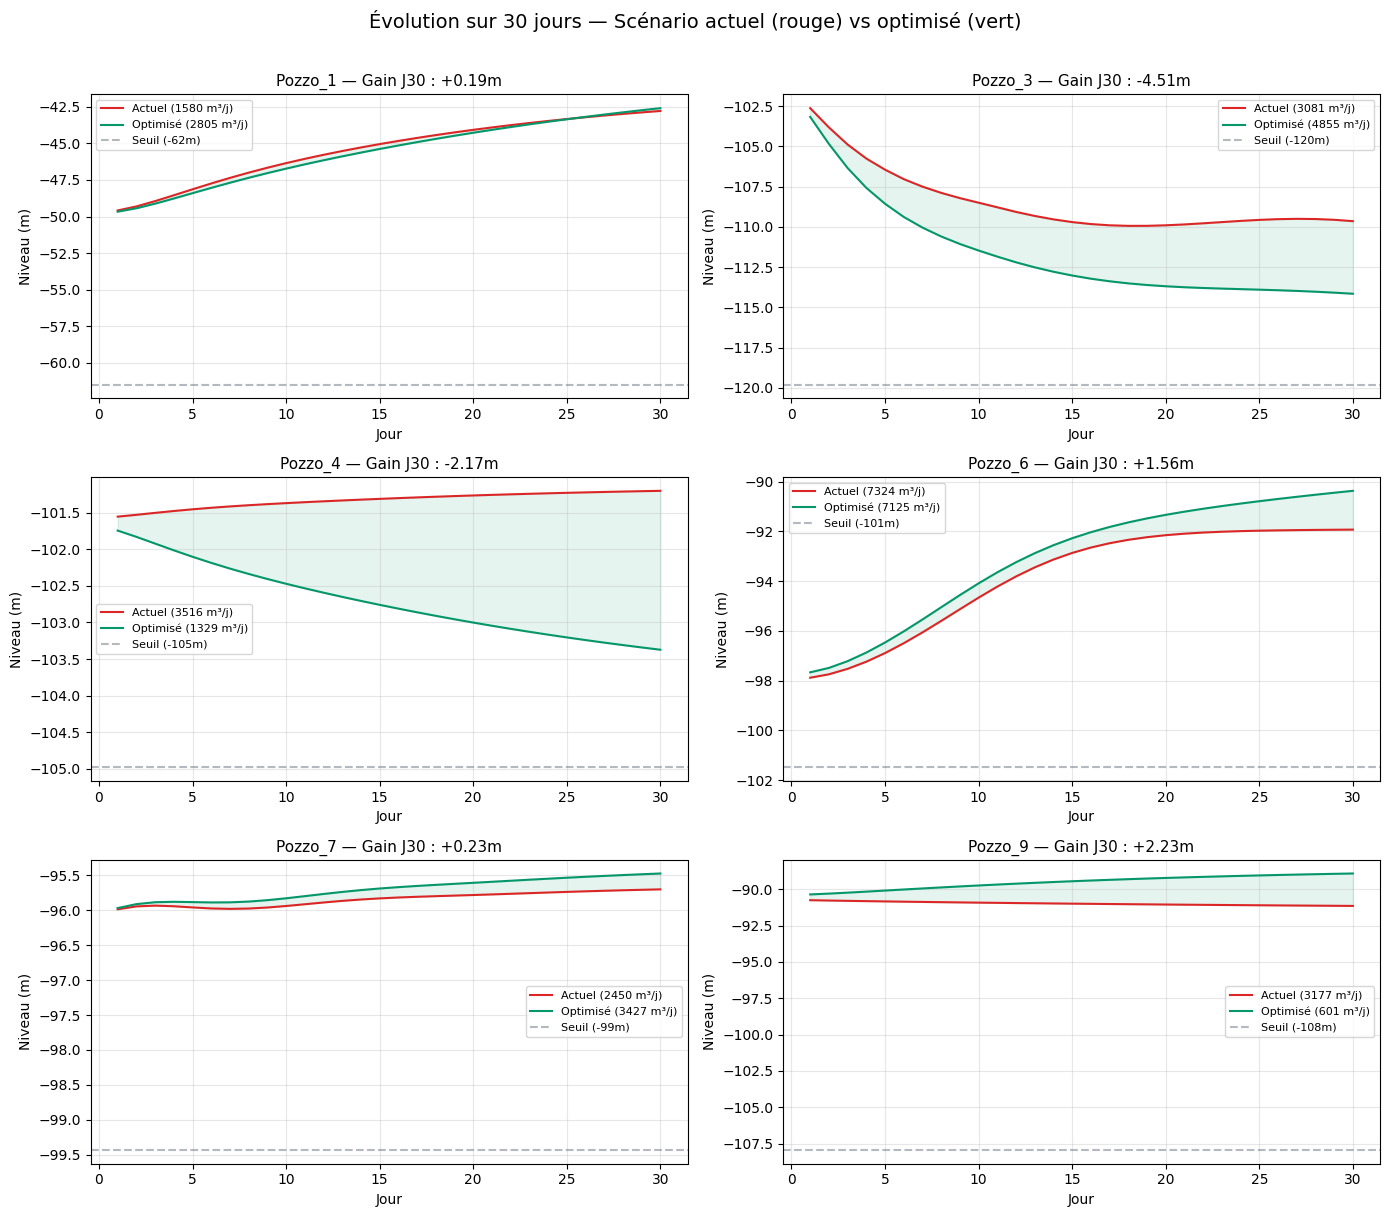

→ Figure sauvegardée dans data/processed/


In [68]:
# === Simuler les 30 jours pour les 2 scénarios (tous les puits) ===

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
jours = list(range(1, 31))

for idx, puits in enumerate(PUITS_AG):
    ax = axes[idx]
    voisins = VOISINS[puits]
    
    # Débits voisins — scénario actuel
    dv_act = {}
    for v in voisins:
        if v in debits_act_r:
            dv_act[v] = debits_act_r[v]
        else:
            dv_act[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
    
    # Débits voisins — scénario optimisé
    dv_opt = {}
    for v in voisins:
        if v in debits_opt_r:
            dv_opt[v] = debits_opt_r[v]
        else:
            dv_opt[v] = pompage_exclus.get(v, df_clean[VOLUME_MAP[v]].mean())
    
    # Simuler 30 jours
    niv_act = simuler_puits_recursif(puits, debits_act_r[puits], dv_act, 30)
    niv_opt = simuler_puits_recursif(puits, debits_opt_r[puits], dv_opt, 30)
    
    seuil = contraintes[puits]['seuil']
    debit_act = contraintes[puits]['vol_mean']
    debit_opt = debits_opt_r[puits]
    
    # Tracer
    ax.plot(jours, niv_act, color='#DC2626', linewidth=1.5, 
            label=f'Actuel ({debit_act:.0f} m³/j)')
    ax.plot(jours, niv_opt, color='#059669', linewidth=1.5, 
            label=f'Optimisé ({debit_opt:.0f} m³/j)')
    ax.axhline(y=seuil, color='#6B7280', linestyle='--', alpha=0.5, 
               label=f'Seuil ({seuil:.0f}m)')
    
    # Colorier la zone de gain (entre les 2 courbes)
    ax.fill_between(jours, niv_act, niv_opt, alpha=0.1, color='#059669')
    
    gain = niv_opt[-1] - niv_act[-1]
    ax.set_title(f'{puits} — Gain J30 : {gain:+.2f}m', fontsize=11)
    ax.set_xlabel('Jour')
    ax.set_ylabel('Niveau (m)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Évolution sur 30 jours — Scénario actuel (rouge) vs optimisé (vert)', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_evolution_30j_actuel_vs_optimise.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

## Conclusion de l'optimisation

### Résultats obtenus

L'algorithme génétique couplé aux LSTM et à la théorie des graphes a trouvé un plan de pompage optimisé qui :

1. **Respecte tous les seuils critiques** - aucune violation sur 30 jours
2. **Améliore le score de fitness** de +29.59 points par rapport au scénario actuel
3. **Satisfait la demande** à 95% (20142 / 21128 m³/jour)

### Stratégie identifiée par l'AG

| Puits | Variation | Raison |
|-------|-----------|--------|
| Pozzo_4 | -62% | Puits central, zone sous pression (voisin de P2 exclu) |
| Pozzo_9 | -81% | Inversement corrélé au cœur, zone sensible |
| Pozzo_1 | +78% | Grande marge (12m au-dessus du seuil), 2 connexions seulement |
| Pozzo_3 | +58% | Puits isolé (0 connexions), aucun impact sur les voisins |
| Pozzo_7 | +40% | Puits isolé (0 connexions), aucun impact sur les voisins |
| Pozzo_6 | ≈ 0% | Maintenu, déjà le plus gros contributeur |

### Le rôle de chaque composante

- **Théorie des graphes** : a identifié les puits centraux (à protéger) et les puits isolés (exploitables sans risque)
- **LSTM** : a simulé l'impact du pompage sur chaque puits, permettant à l'AG d'évaluer chaque combinaison
- **AG** : a exploré des milliers de combinaisons et trouvé le meilleur compromis entre demande et préservation

### Comparaison AG simple vs AG récursif

| Critère | AG simple | AG récursif |
|---------|-----------|-------------|
| Violations de seuil | 1 (Pozzo_4) | **0** |
| Pozzo_4 | 0 m³ (arrêt total) | 1329 m³ (réduit) |
| Réalisme | Agressif | **Prudent et viable** |

L'AG récursif (simulation sur 30 jours) produit un plan  
plus réaliste et plus sûr que l'AG simple (1 jour).

### Fichiers sauvegardés

- 9 modèles LSTM : `models/lstm_pozzo_X.keras`
- Graphe du réseau : `data/processed/fig_doganella_graphe.png`
- Courbes d'évolution : `data/processed/fig_evolution_30j_actuel_vs_optimise.png`

NameError: name 'modeles_dog' is not defined